## Problem Statement :
-- We have given a sales data of a superstore. 
-- With growing demands and cut-throat competitions in the market, a Superstore Giant is seeking your knowledge in understanding what works best for them. They would like to understand which products regions, categories and customer segments they should target or avoid.

-- I wil build a Regression model to predict Sales or Profit.

-- I will also provide some business insights to improve.

## Dataset Source
-- https://www.kaggle.com/datasets/vivek468/superstore-dataset-final

## Columns : 
1. Row ID => Unique ID for each row. 
2. Order ID => Unique Order ID for each Customer. 
3. Order Date => Order Date of the product. 
4. Ship Date => Shipping Date of the Product. 
5. Ship Mode=> Shipping Mode specified by the Customer. 
6. Customer ID => Unique ID to identify each Customer. 
7. Customer Name => Name of the Customer. 
8. Segment => The segment where the Customer belongs. 
9. Country => Country of residence of the Customer. 
10. City => City of residence of of the Customer. 
11. State => State of residence of the Customer.
12. Postal Code => Postal Code of every Customer. 
13. Region => Region where the Customer belong. 
14. Product ID => Unique ID of the Product. 
15. Category => Category of the product ordered. 
16. Sub-Category => Sub-Category of the product ordered. 
17. Product Name => Name of the Product 
18. Sales => Sales of the Product. 
19. Quantity => Quantity of the Product. 
20. Discount => Discount provided. 
21. Profit => Profit/Loss incurred.


## Steps I am going to do:
 1. Data cleaning:
    -- Null values
    -- Handling null values
    -- Duplicate rows 

2. Feature Engineering:
    -- Data transformation
    -- Feature Engineering
    -- Feature Scaling if needed

3. Data analysis:
    -- Plotting graph 
    -- Visualization using matplotlib and seaborn

4. Extracting insights

In [1]:
## Importing Important libraries for EDA

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns


KeyboardInterrupt: 

In [ ]:
## Encoding characters of the dataset
import chardet
FILE_PATH = "../data/raw/Sample - Superstore.csv"
with open(FILE_PATH, "rb") as f:
    result = chardet.detect(f.read())

print(result)

{'encoding': 'Windows-1252', 'confidence': 0.73, 'language': ''}


In [ ]:
## Load and Read data 
df = pd.read_csv(FILE_PATH, encoding="Windows-1252")



In [ ]:
pd.set_option('display.max_columns', None) ## Show all columns 

(df.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
## Null Values  
df.isnull().sum()

## No null values - cleaned data

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [ ]:
## Duplicate Rows
df.duplicated().sum()

## Not any duplicated records

np.int64(0)

In [ ]:
## Statistical analysis
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## Statistical analysis - Insights 

-- Maximum sales = 22638.480000

-- Maximum quantity of a product sold = 14

-- Highest Discount = 80%

-- Highest profit = 8399.9760



-- Minimum sales = 0.444000

-- Minimum quantity of a product sold = 1

-- Minimum Discount = 0%

-- Maximum Loss = -6599.978000



## Customers whose sales is between 0 and 1

In [ ]:
customers = df[(df['Sales'] > 0) & (df['Sales'] < 1)]
customers

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
2106,2107,US-2014-152723,9/26/2014,9/26/2014,Same Day,HG-14965,Henry Goldwyn,Corporate,United States,Mesquite,Texas,75150,Central,OFF-BI-10003460,Office Supplies,Binders,Acco 3-Hole Punch,0.876,1,0.8,-1.4016
2761,2762,CA-2017-126536,10/12/2017,10/14/2017,First Class,NK-18490,Neil Knudson,Home Office,United States,San Francisco,California,94110,West,TEC-AC-10003709,Technology,Accessories,Maxell 4.7GB DVD-R 5/Pack,0.990,1,0.0,0.4356
4101,4102,US-2017-102288,6/19/2017,6/23/2017,Standard Class,ZC-21910,Zuschuss Carroll,Consumer,United States,Houston,Texas,77095,Central,OFF-AP-10002906,Office Supplies,Appliances,Hoover Replacement Belt for Commercial Guardsm...,0.444,1,0.8,-1.1100
4711,4712,CA-2014-112403,3/31/2014,3/31/2014,Same Day,JO-15280,Jas O'Carroll,Consumer,United States,Philadelphia,Pennsylvania,19120,East,OFF-BI-10003529,Office Supplies,Binders,Avery Round Ring Poly Binders,0.852,1,0.7,-0.5964
7548,7549,CA-2014-103492,10/10/2014,10/15/2014,Standard Class,CM-12715,Craig Molinari,Corporate,United States,Huntsville,Texas,77340,Central,OFF-BI-10004140,Office Supplies,Binders,Avery Non-Stick Binders,0.898,1,0.8,-1.5715
8033,8034,CA-2015-119690,6/25/2015,6/28/2015,First Class,MV-17485,Mark Van Huff,Consumer,United States,Houston,Texas,77041,Central,OFF-BI-10000201,Office Supplies,Binders,"Avery Triangle Shaped Sheet Lifters, Black, 2/...",0.984,2,0.8,-1.4760
8658,8659,CA-2016-168361,6/21/2016,6/25/2016,Standard Class,KB-16600,Ken Brennan,Corporate,United States,Chicago,Illinois,60623,Central,OFF-BI-10003727,Office Supplies,Binders,Avery Durable Slant Ring Binders With Label Ho...,0.836,1,0.8,-1.3376
9292,9293,CA-2017-124114,3/2/2017,3/2/2017,Same Day,RS-19765,Roland Schwarz,Corporate,United States,Waco,Texas,76706,Central,OFF-BI-10004022,Office Supplies,Binders,Acco Suede Grain Vinyl Round Ring Binder,0.556,1,0.8,-0.9452


In [ ]:
df['Category'].unique()

array(['Furniture', 'Office Supplies', 'Technology'], dtype=object)

In [ ]:
## Total number of sales of each category of product
df.groupby('Category')['Sales'].sum()

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

## Insight of category :
-- The technical product sold most -sales of 836154.0330

-- The Office Supplies product sold most -sales of 719047.0320

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
df['Segment'].unique()

array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

In [ ]:
## Dropping column "Row id" - unnecessary
df.drop('Row ID',axis=1,inplace=True)

In [ ]:
len(df['Order Date'].unique())

1237

In [ ]:
## Extracting month and year from the order date
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Order Date'])

In [ ]:

df['Order_day'] = df['Order Date'].dt.day
df['Order_month'] = df['Order Date'].dt.month
df['Order_year'] = df['Order Date'].dt.year

df['Ship_day'] = df['Ship Date'].dt.day
df['Ship_month'] = df['Ship Date'].dt.month
df['Ship_year'] = df['Ship Date'].dt.year

In [ ]:
def discount_category(x):
    if x == 0:
        return 'No Discount'
    elif x <= 0.2:
        return 'Low Discount'
    elif x <= 0.5:
        return 'Medium Discount'
    else:
        return 'High Discount'

df['Discount Category'] = df['Discount'].apply(discount_category)



In [ ]:
def order_size(q):
    if q <= 2:
        return 'Small'
    elif q <= 5:
        return 'Medium'
    else:
        return 'Large'

df['Order Size'] = df['Quantity'].apply(order_size)



In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df['Shipping Time'] = (df['Ship Date'] - df['Order Date']).dt.days

df[['Order Date','Ship Date','Shipping Time']].head()

,Order Date,Ship Date,Shipping Time
0,2016-11-08,2016-11-08,0
1,2016-11-08,2016-11-08,0
2,2016-06-12,2016-06-12,0
3,2015-10-11,2015-10-11,0
4,2015-10-11,2015-10-11,0


In [ ]:
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order_day,Order_month,Order_year,Ship_day,Ship_month,Ship_year,Discount Category,Order Size,Shipping Time
0,CA-2016-152156,2016-11-08,2016-11-08,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,8,11,2016,8,11,2016,No Discount,Small,0
1,CA-2016-152156,2016-11-08,2016-11-08,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,8,11,2016,8,11,2016,No Discount,Medium,0
2,CA-2016-138688,2016-06-12,2016-06-12,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,12,6,2016,12,6,2016,No Discount,Small,0
3,US-2015-108966,2015-10-11,2015-10-11,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,11,10,2015,11,10,2015,Medium Discount,Medium,0
4,US-2015-108966,2015-10-11,2015-10-11,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,11,10,2015,11,10,2015,Low Discount,Small,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order ID           9994 non-null   object        
 1   Order Date         9994 non-null   datetime64[ns]
 2   Ship Date          9994 non-null   datetime64[ns]
 3   Ship Mode          9994 non-null   object        
 4   Customer ID        9994 non-null   object        
 5   Customer Name      9994 non-null   object        
 6   Segment            9994 non-null   object        
 7   Country            9994 non-null   object        
 8   City               9994 non-null   object        
 9   State              9994 non-null   object        
 10  Postal Code        9994 non-null   int64         
 11  Region             9994 non-null   object        
 12  Product ID         9994 non-null   object        
 13  Category           9994 non-null   object        
 14  Sub-Cate

In [ ]:
df['Country'].unique()

array(['United States'], dtype=object)

In [ ]:
df['Order_month_name'] = df['Order_month'].map({1:'January',2:'February',3:'March',4:'April',5:'May',6:'June',7:'july',8:'August',9:'September',10:'October',11:'November',12:'December'})
df['Ship_month_name'] = df['Ship_month'].map({1:'January',2:'February',3:'March',4:'April',5:'May',6:'June',7:'july',8:'August',9:'September',10:'October',11:'November',12:'December'})

In [ ]:
df['City'].unique()

array(['Henderson', 'Los Angeles', 'Fort Lauderdale', 'Concord',
       'Seattle', 'Fort Worth', 'Madison', 'West Jordan', 'San Francisco',
       'Fremont', 'Philadelphia', 'Orem', 'Houston', 'Richardson',
       'Naperville', 'Melbourne', 'Eagan', 'Westland', 'Dover',
       'New Albany', 'New York City', 'Troy', 'Chicago', 'Gilbert',
       'Springfield', 'Jackson', 'Memphis', 'Decatur', 'Durham',
       'Columbia', 'Rochester', 'Minneapolis', 'Portland', 'Saint Paul',
       'Aurora', 'Charlotte', 'Orland Park', 'Urbandale', 'Columbus',
       'Bristol', 'Wilmington', 'Bloomington', 'Phoenix', 'Roseville',
       'Independence', 'Pasadena', 'Newark', 'Franklin', 'Scottsdale',
       'San Jose', 'Edmond', 'Carlsbad', 'San Antonio', 'Monroe',
       'Fairfield', 'Grand Prairie', 'Redlands', 'Hamilton', 'Westfield',
       'Akron', 'Denver', 'Dallas', 'Whittier', 'Saginaw', 'Medina',
       'Dublin', 'Detroit', 'Tampa', 'Santa Clara', 'Lakeville',
       'San Diego', 'Brentwood', 'Cha

In [ ]:
df['State'].unique()

array(['Kentucky', 'California', 'Florida', 'North Carolina',
       'Washington', 'Texas', 'Wisconsin', 'Utah', 'Nebraska',
       'Pennsylvania', 'Illinois', 'Minnesota', 'Michigan', 'Delaware',
       'Indiana', 'New York', 'Arizona', 'Virginia', 'Tennessee',
       'Alabama', 'South Carolina', 'Oregon', 'Colorado', 'Iowa', 'Ohio',
       'Missouri', 'Oklahoma', 'New Mexico', 'Louisiana', 'Connecticut',
       'New Jersey', 'Massachusetts', 'Georgia', 'Nevada', 'Rhode Island',
       'Mississippi', 'Arkansas', 'Montana', 'New Hampshire', 'Maryland',
       'District of Columbia', 'Kansas', 'Vermont', 'Maine',
       'South Dakota', 'Idaho', 'North Dakota', 'Wyoming',
       'West Virginia'], dtype=object)

In [ ]:
df.columns

Index(['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID',
       'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name',
       'Sales', 'Quantity', 'Discount', 'Profit', 'Order_day', 'Order_month',
       'Order_year', 'Ship_day', 'Ship_month', 'Ship_year',
       'Discount Category', 'Order Size', 'Shipping Time', 'Order_month_name',
       'Ship_month_name'],
      dtype='object')

In [ ]:
df.describe(include='object')

,Order ID,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Discount Category,Order Size,Order_month_name,Ship_month_name
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,4,793,793,3,1,531,49,4,1862,3,17,1850,4,3,12,12
top,CA-2017-100111,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,No Discount,Medium,November,November
freq,14,5968,37,37,5191,9994,915,2001,3203,19,6026,1523,48,4798,4830,1471,1471


In [ ]:
## IQR method for outliers for Sales column:

q1 = df['Sales'].quantile(0.25)
q3 = df['Sales'].quantile(0.75)
iqr = q3-q1
lower_fence = q1 - 1.5*(iqr)
upper_fence = q3 + 1.5*(iqr)
print("Q1 : ",q1)
print("Q3 : ",q3)
print("IQR : ",iqr)
print("Lower : ",lower_fence)
print("Upper : ",upper_fence)

Q1 :  17.28
Q3 :  209.94
IQR :  192.66
Lower :  -271.71000000000004
Upper :  498.93


In [ ]:
## IQR method for outliers for Discount column:

q1 = df['Discount'].quantile(0.25)
q3 = df['Discount'].quantile(0.75)
iqr = q3-q1
lower_fence = q1 - 1.5*(iqr)
upper_fence = q3 + 1.5*(iqr)
print("Q1 : ",q1)
print("Q3 : ",q3)
print("IQR : ",iqr)
print("Lower : ",lower_fence)
print("Upper : ",upper_fence)

Q1 :  0.0
Q3 :  0.2
IQR :  0.2
Lower :  -0.30000000000000004
Upper :  0.5


## Univariate Analysis

In [ ]:
num_features = df.select_dtypes(include='number')
cat_features = df.select_dtypes(include='object')

In [ ]:
## Categoriacal feature with less than 10 unique values
low_cardinality_cols = cat_features.loc[:,cat_features.nunique() < 10]

low_cardinality_cols

,Ship Mode,Segment,Country,Region,Category,Discount Category,Order Size
0,Second Class,Consumer,United States,South,Furniture,No Discount,Small
1,Second Class,Consumer,United States,South,Furniture,No Discount,Medium
2,Second Class,Corporate,United States,West,Office Supplies,No Discount,Small
3,Standard Class,Consumer,United States,South,Furniture,Medium Discount,Medium
4,Standard Class,Consumer,United States,South,Office Supplies,Low Discount,Small
...,...,...,...,...,...,...,...
9989,Second Class,Consumer,United States,South,Furniture,Low Discount,Medium
9990,Standard Class,Consumer,United States,West,Furniture,No Discount,Small
9991,Standard Class,Consumer,United States,West,Technology,Low Discount,Small
9992,Standard Class,Consumer,United States,West,Office Supplies,No Discount,Medium


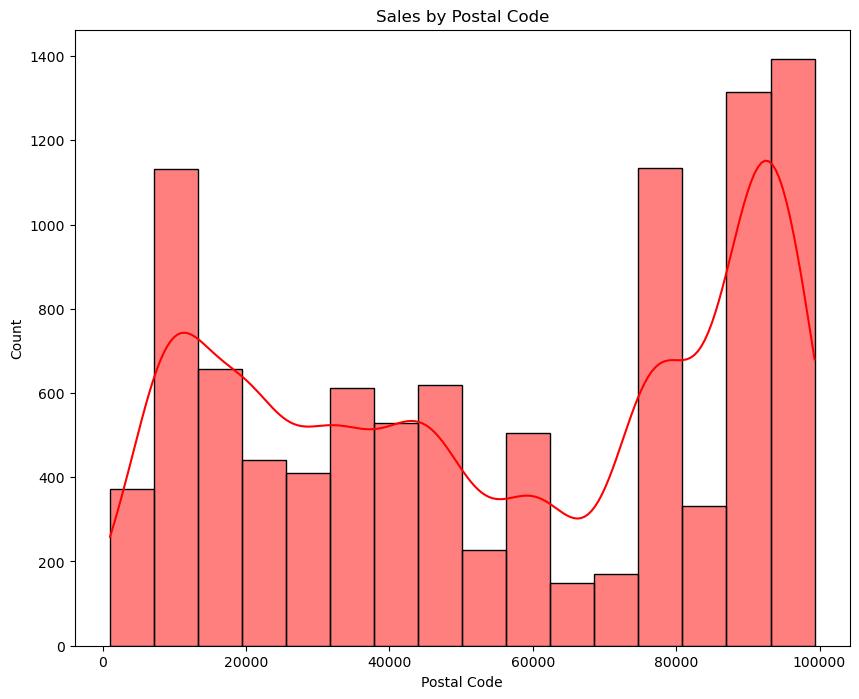

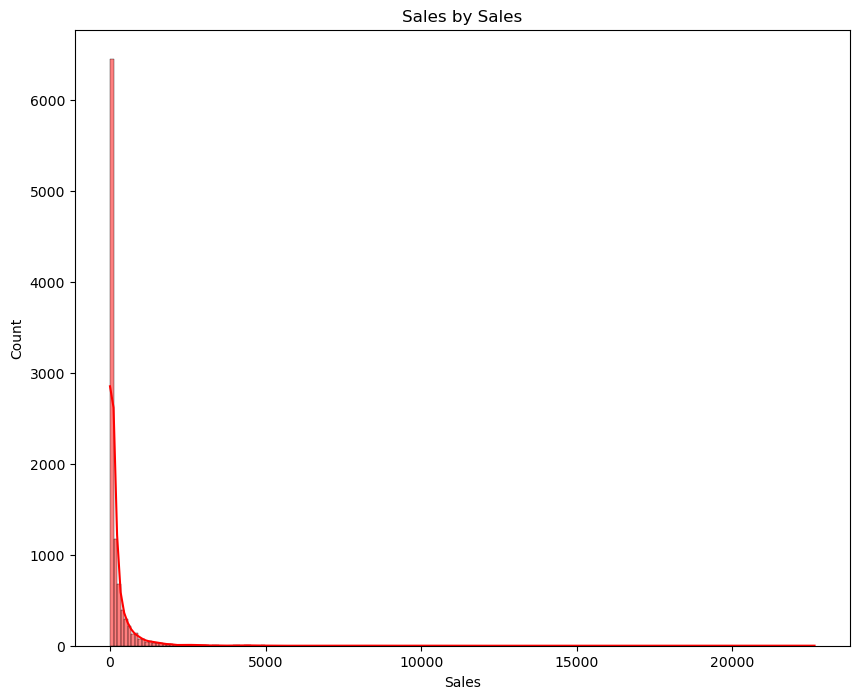

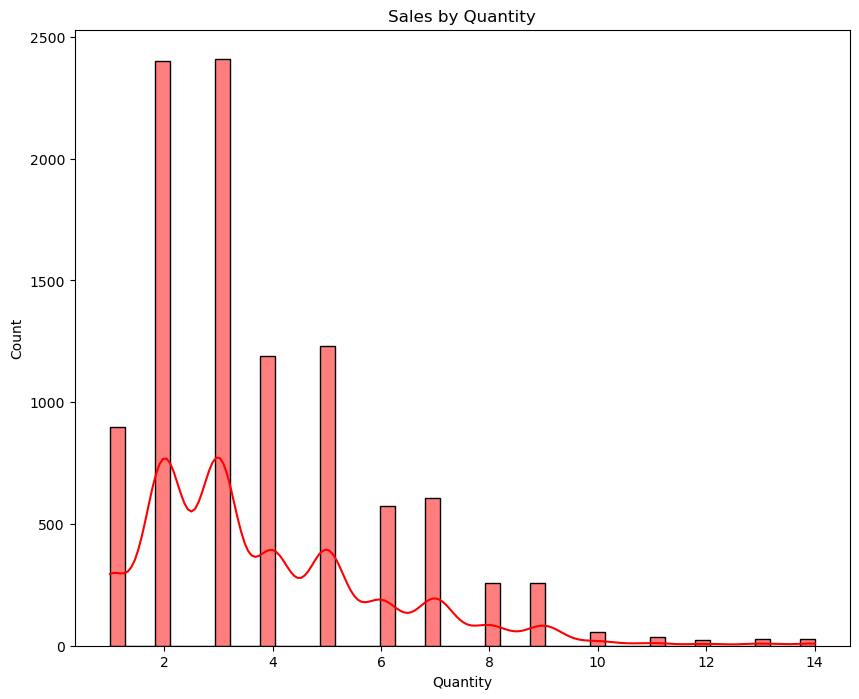

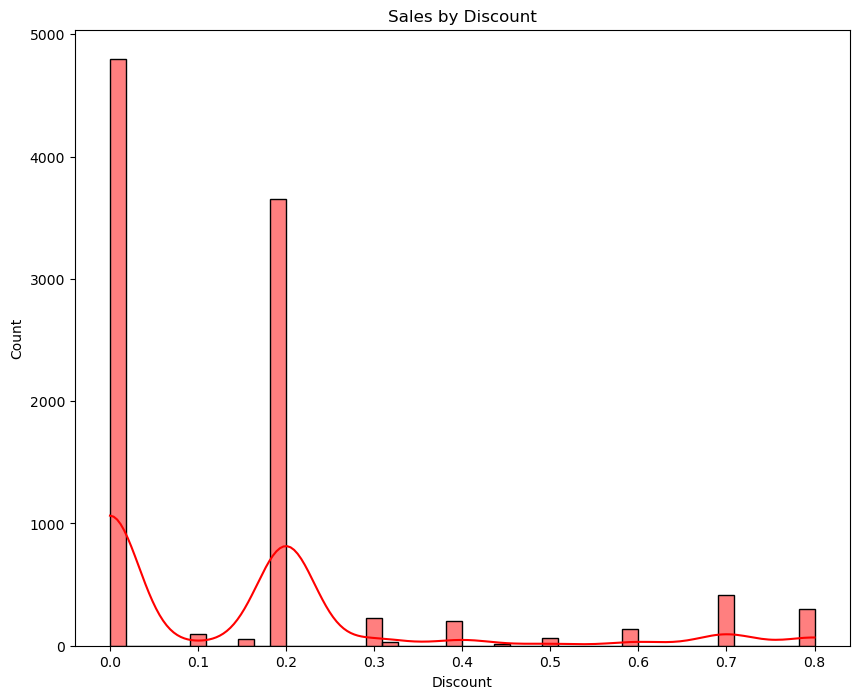

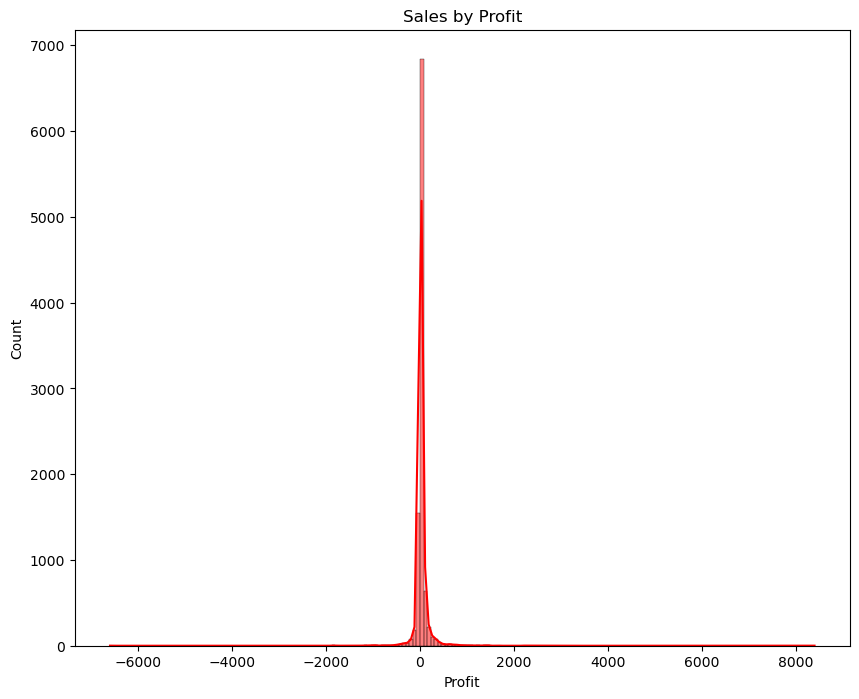

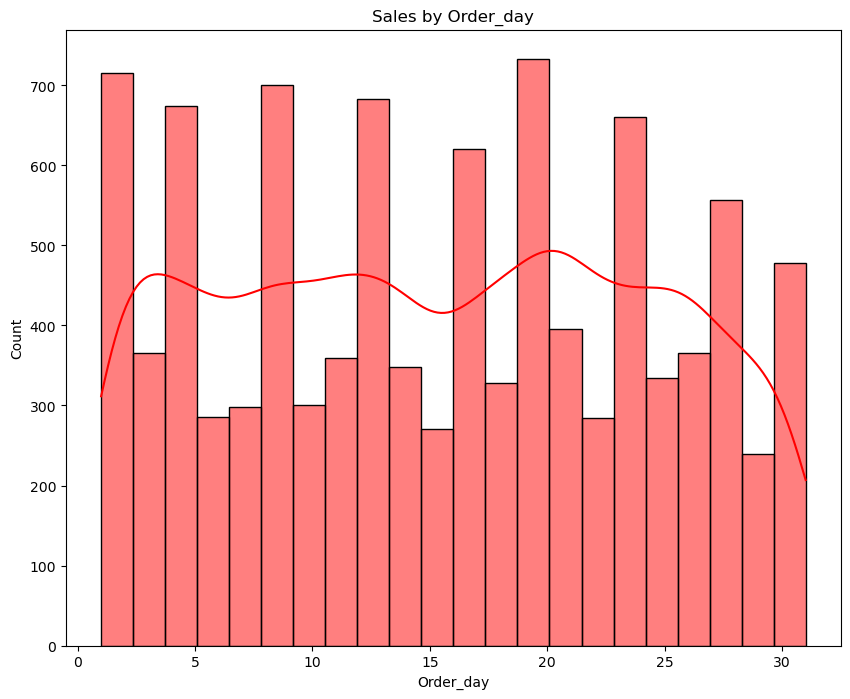

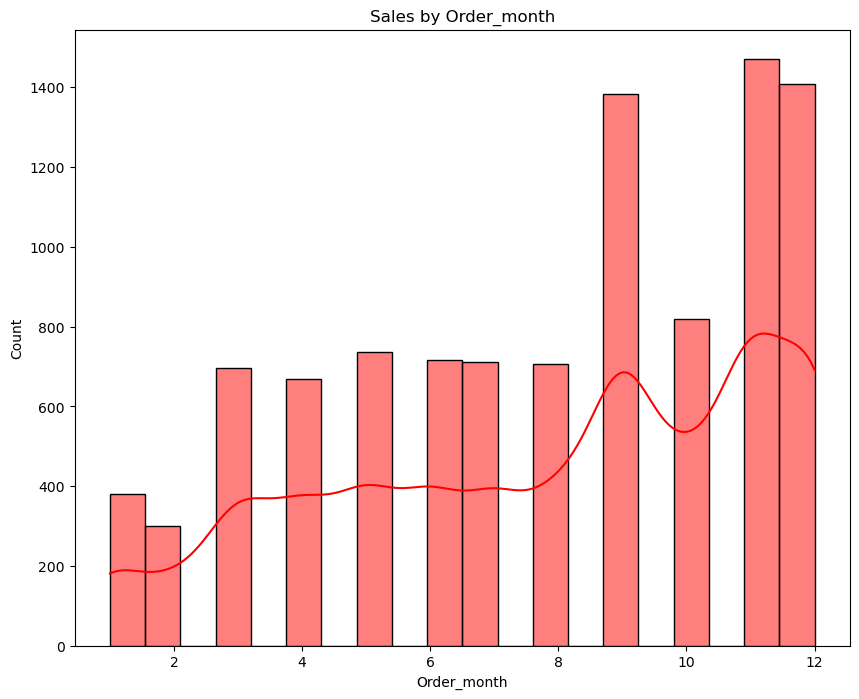

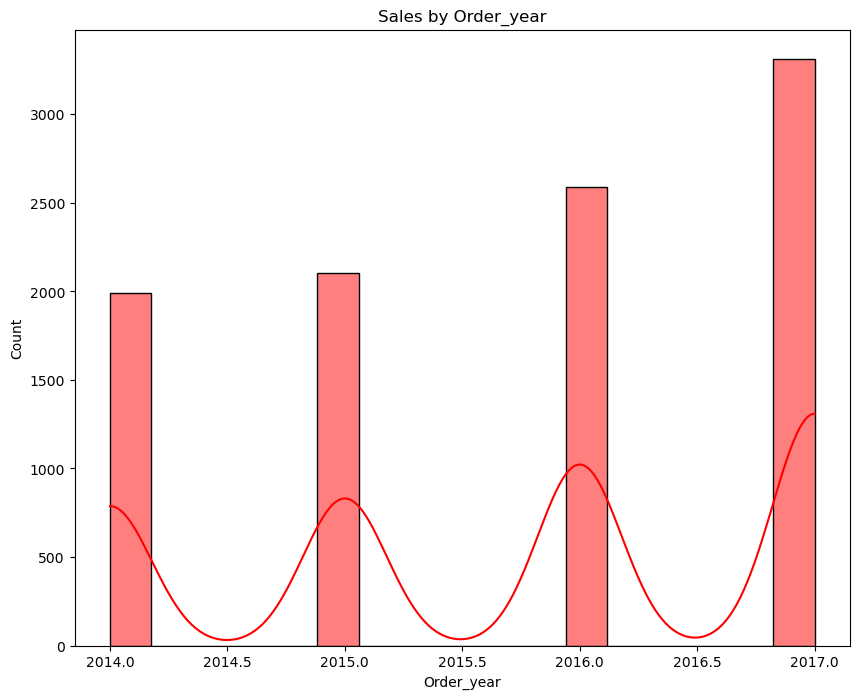

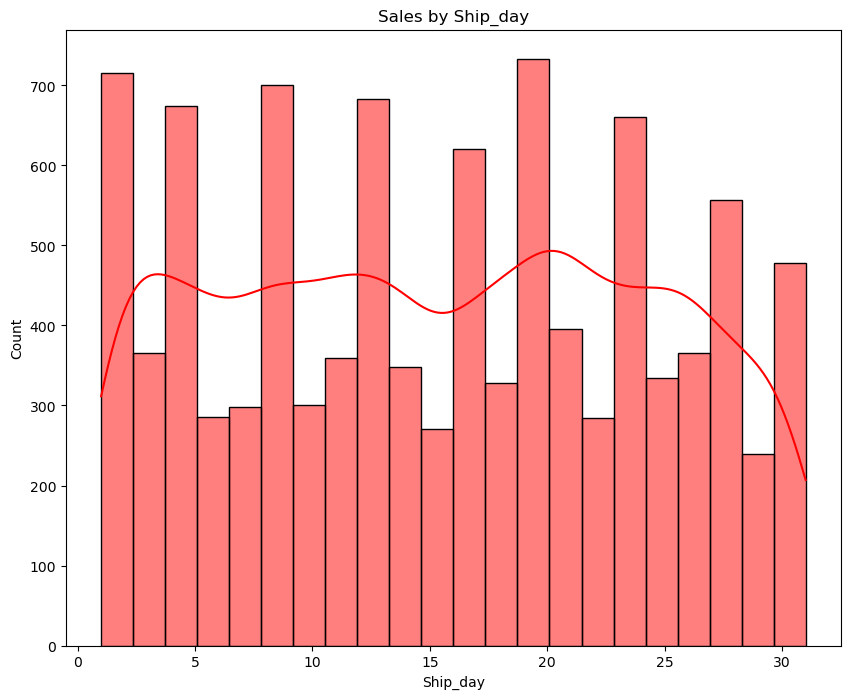

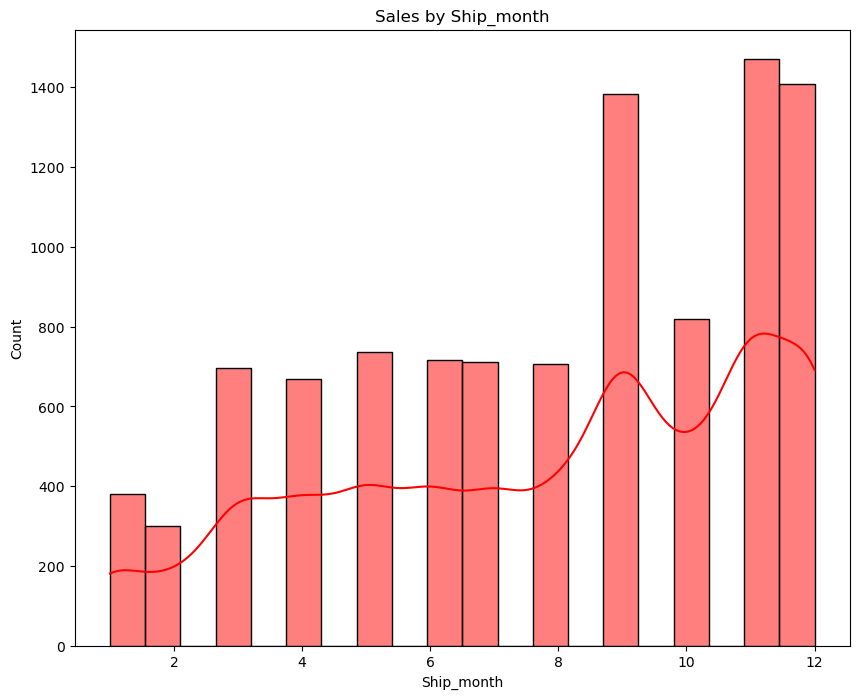

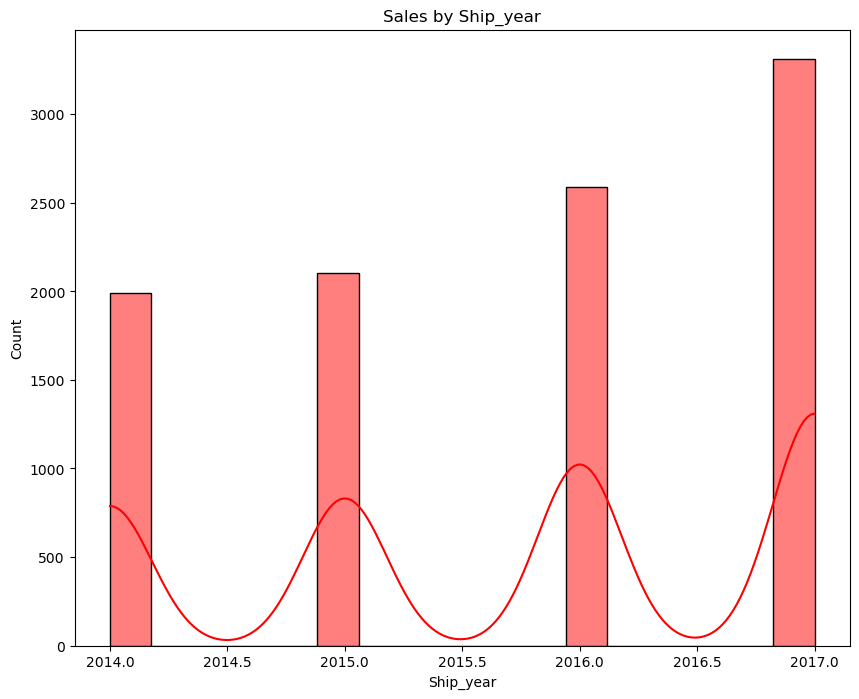

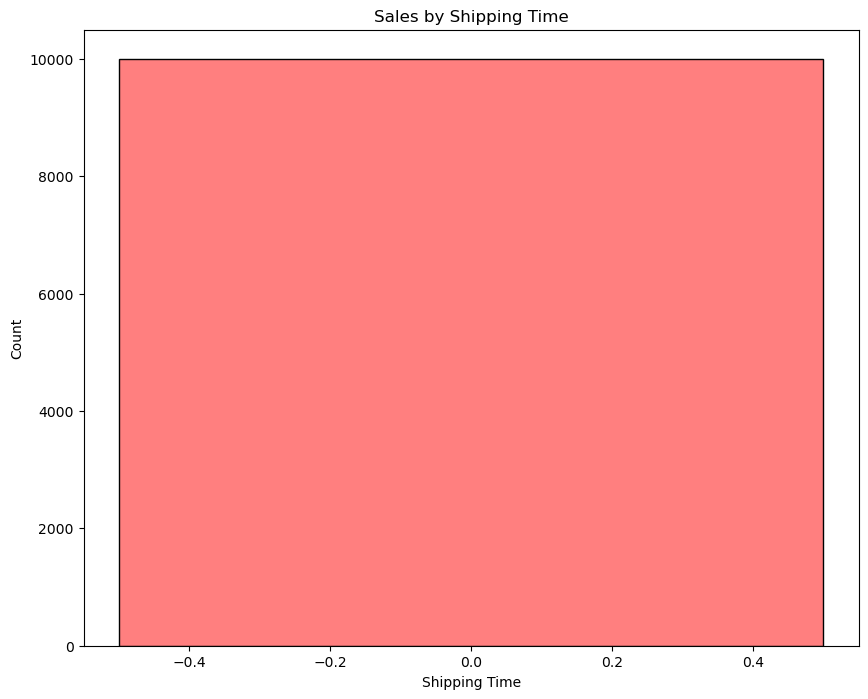

In [ ]:
for col in num_features:
    plt.figure(figsize=(10,8))
    sns.histplot(data=num_features,x=col,kde=True,color='r')
    plt.title(f"Sales by {col}")
    plt.xlabel(col)
    plt.show()

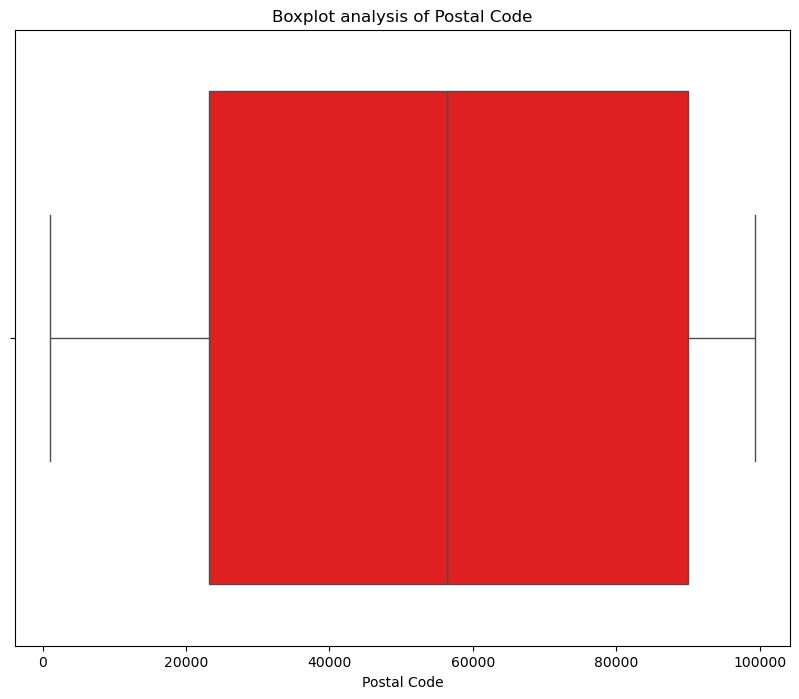

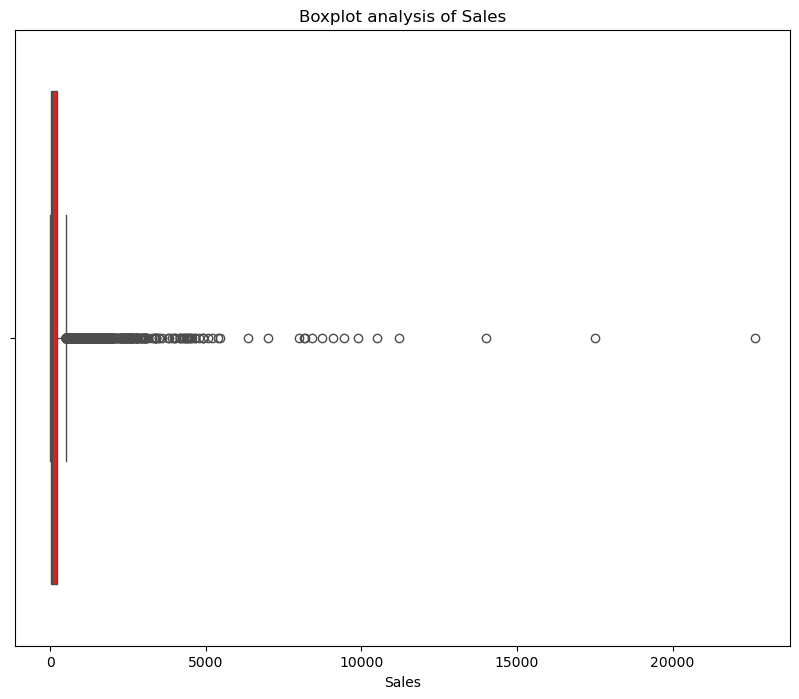

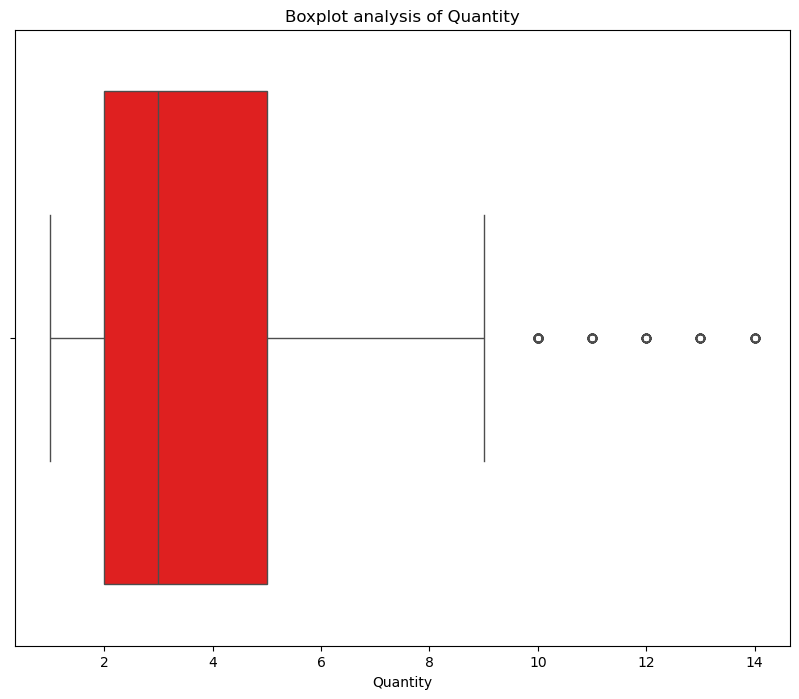

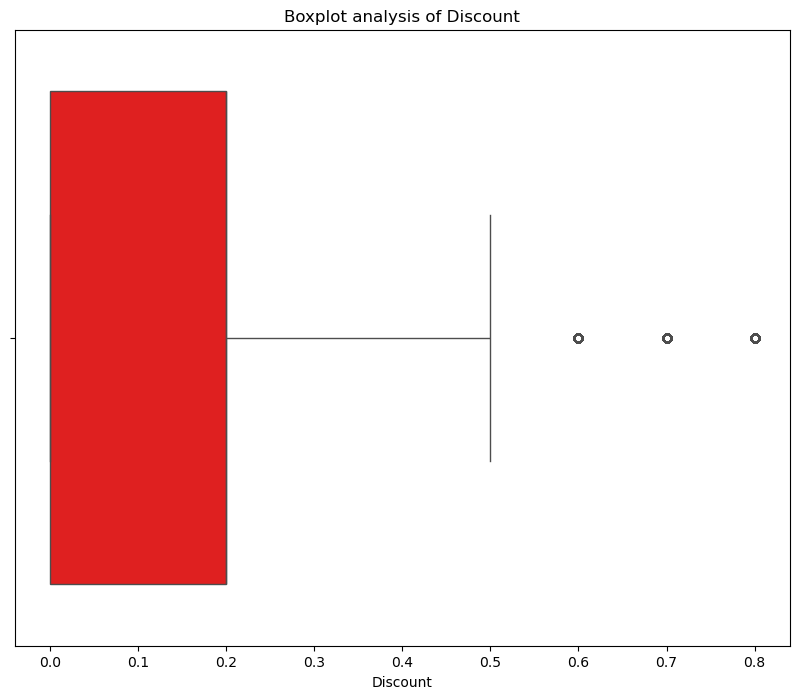

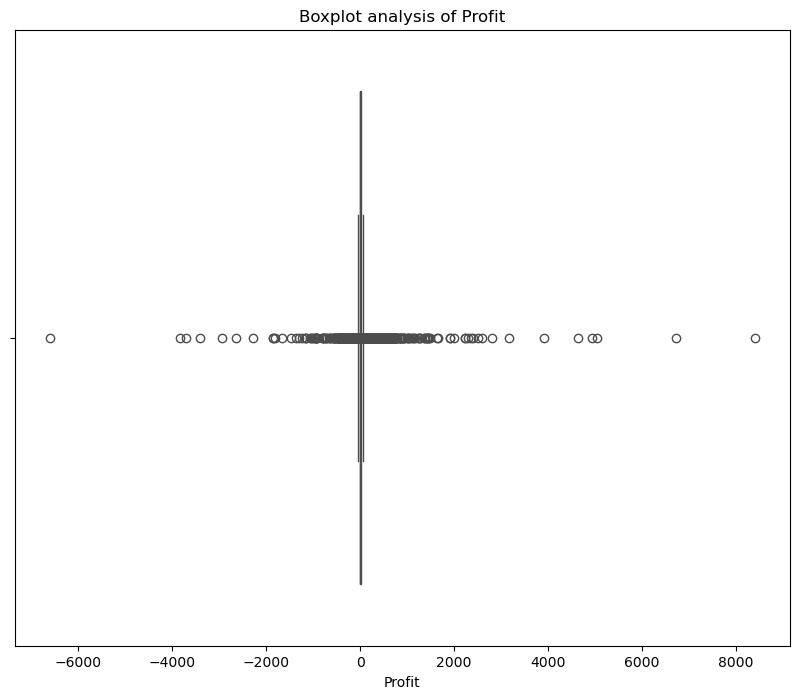

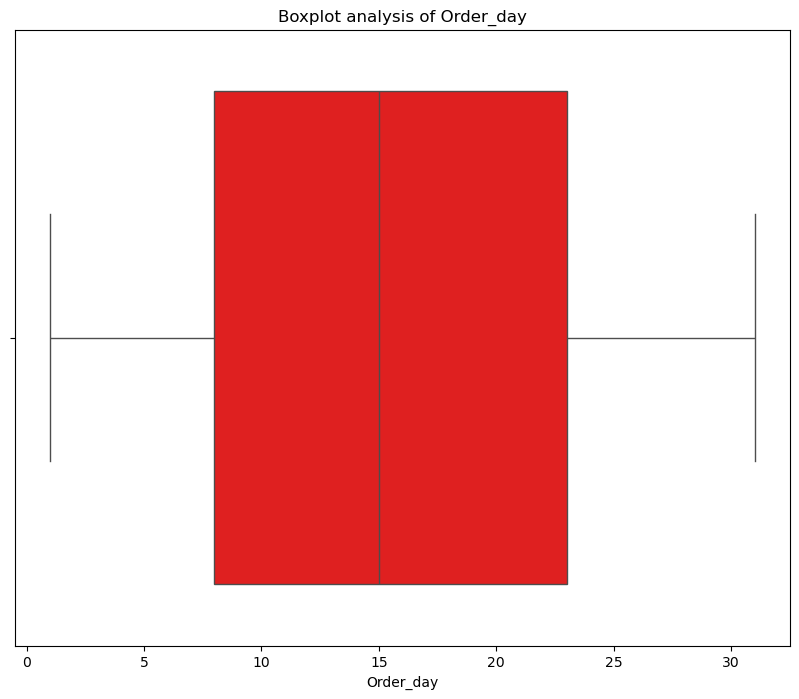

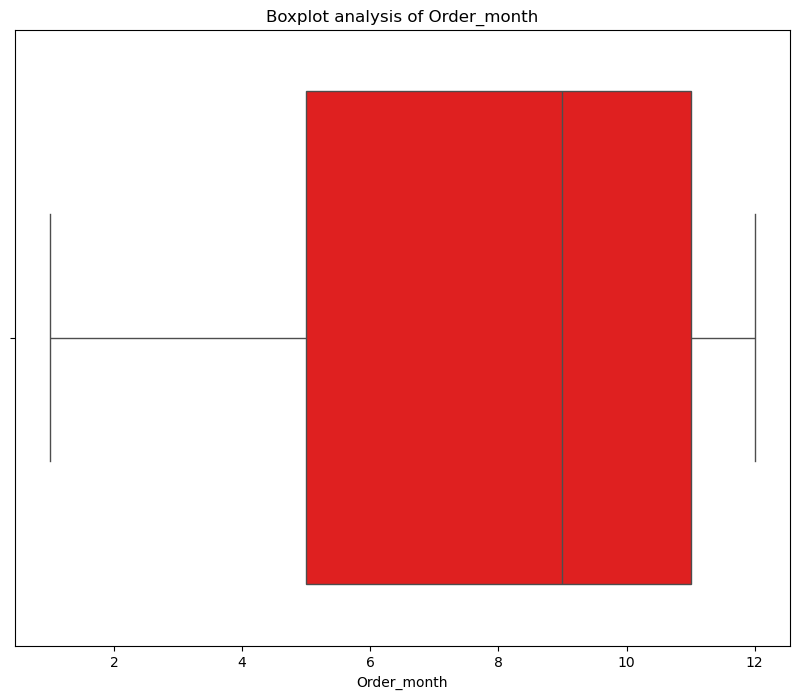

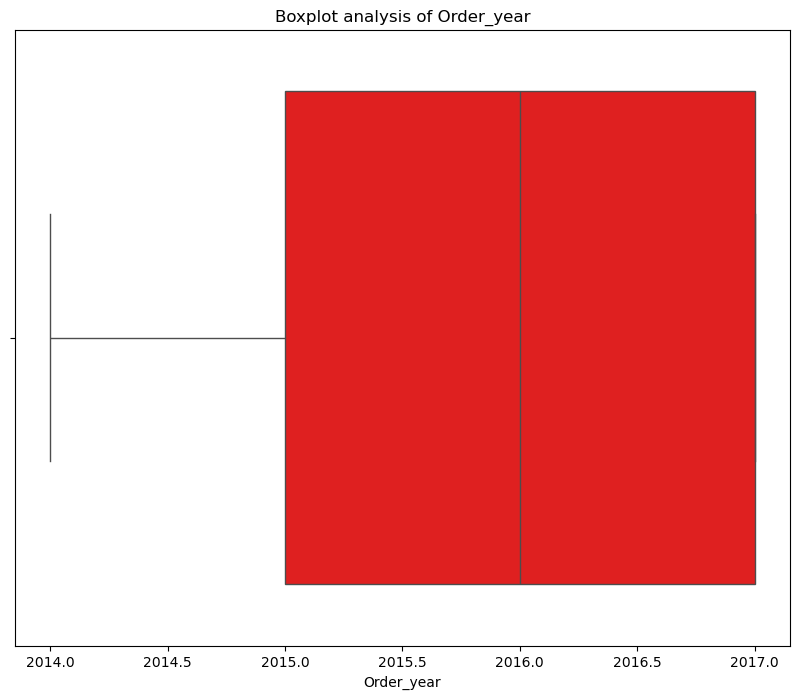

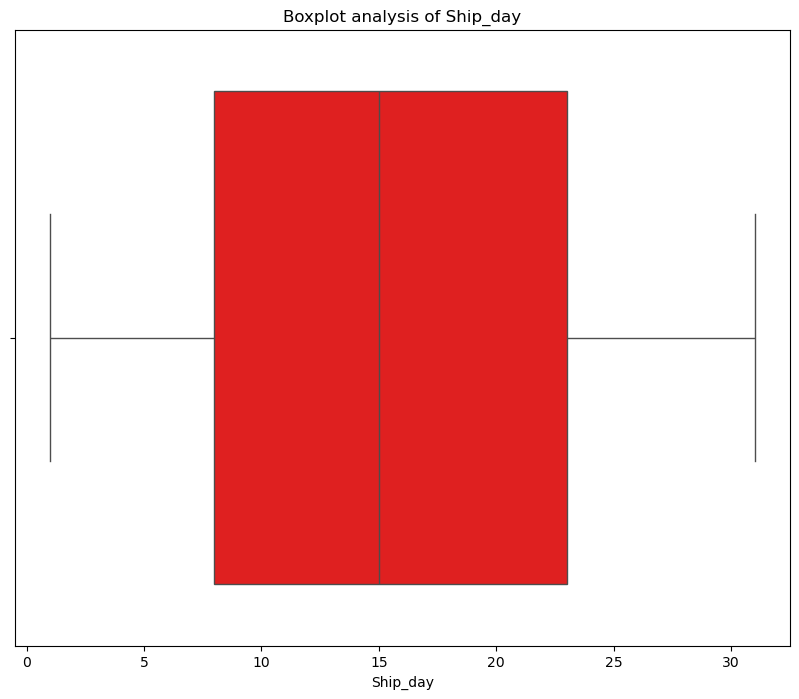

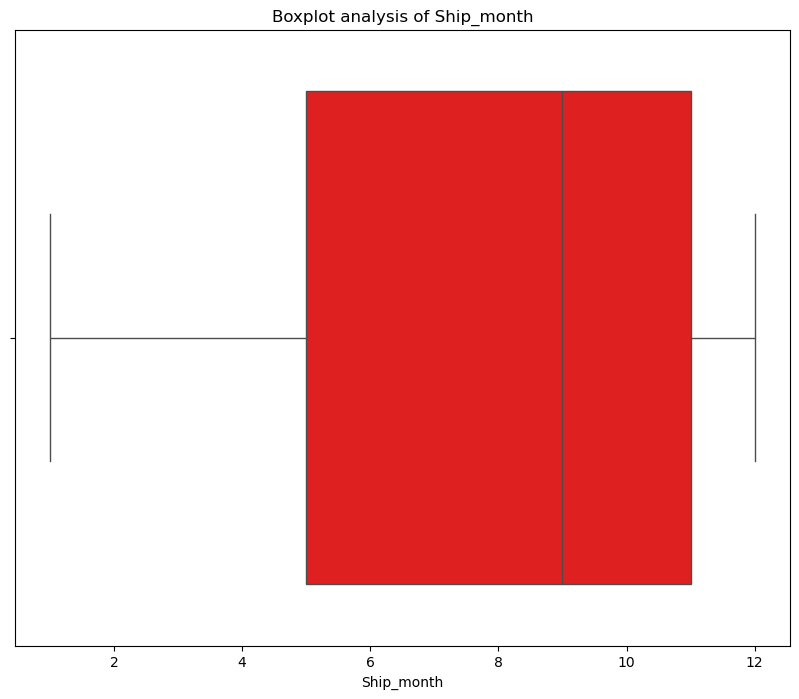

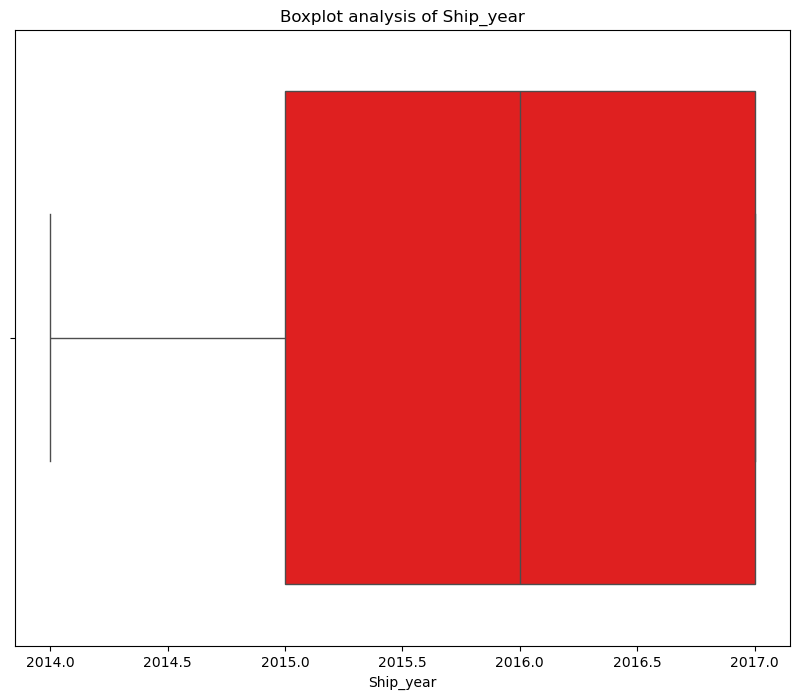

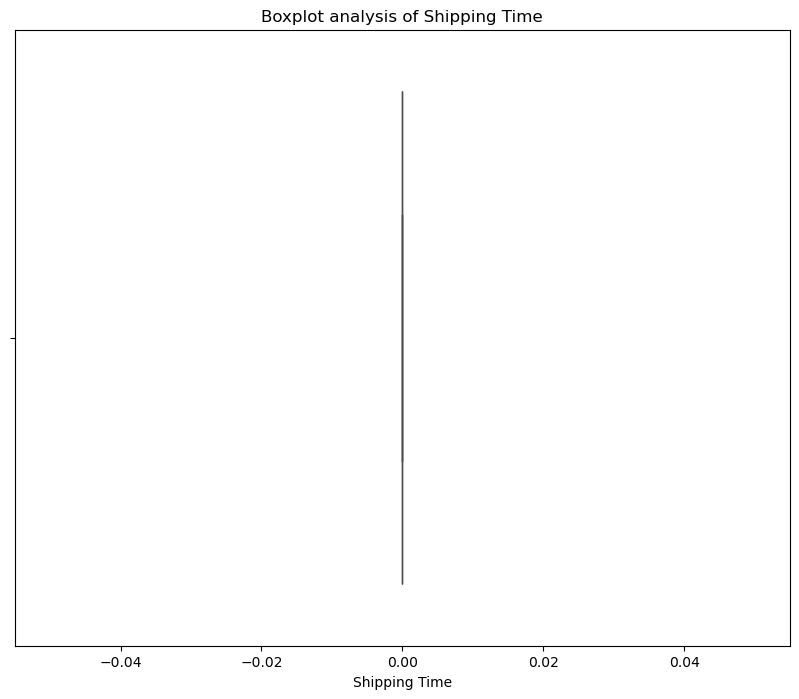

In [ ]:
for col in num_features:
    plt.figure(figsize=(10,8))
    sns.boxplot(data=num_features,x=col,color='r')
    plt.title(f"Boxplot analysis of {col}")
    plt.xlabel(col)
    plt.show()

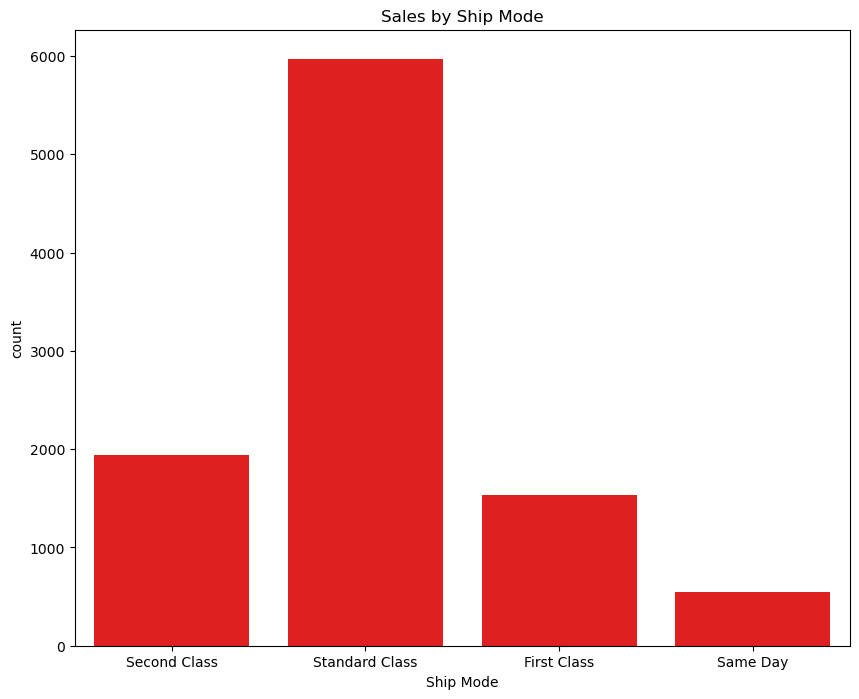

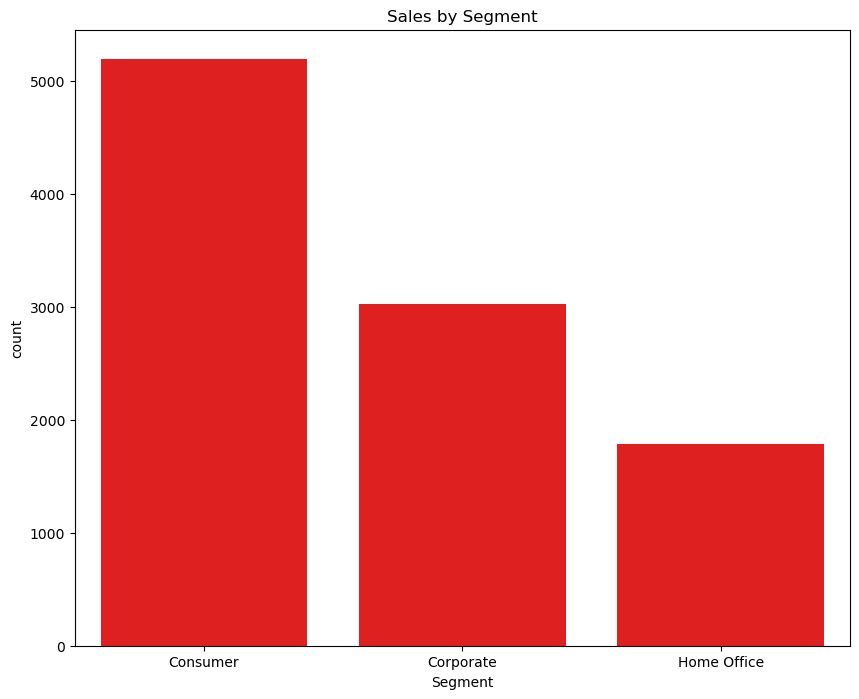

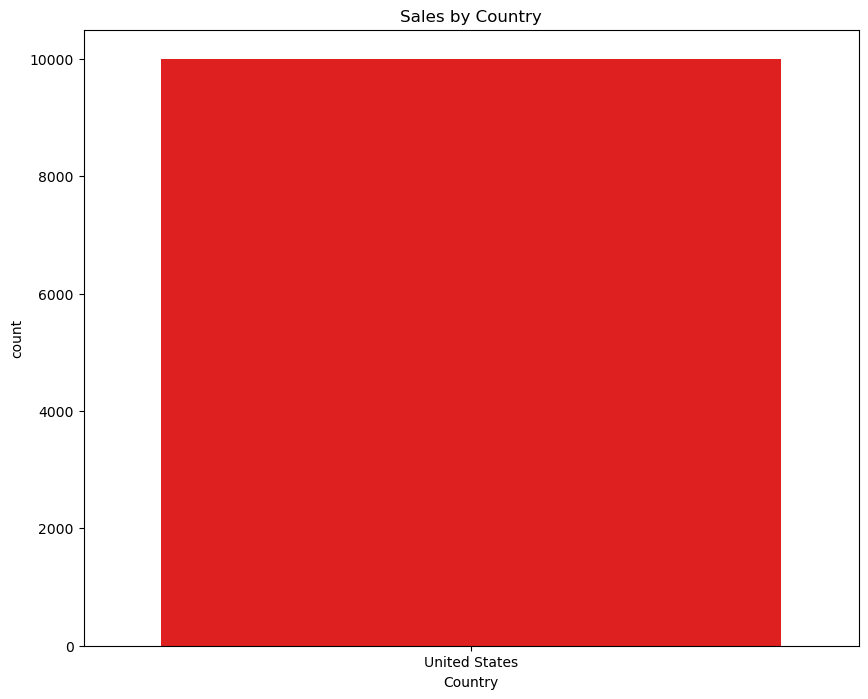

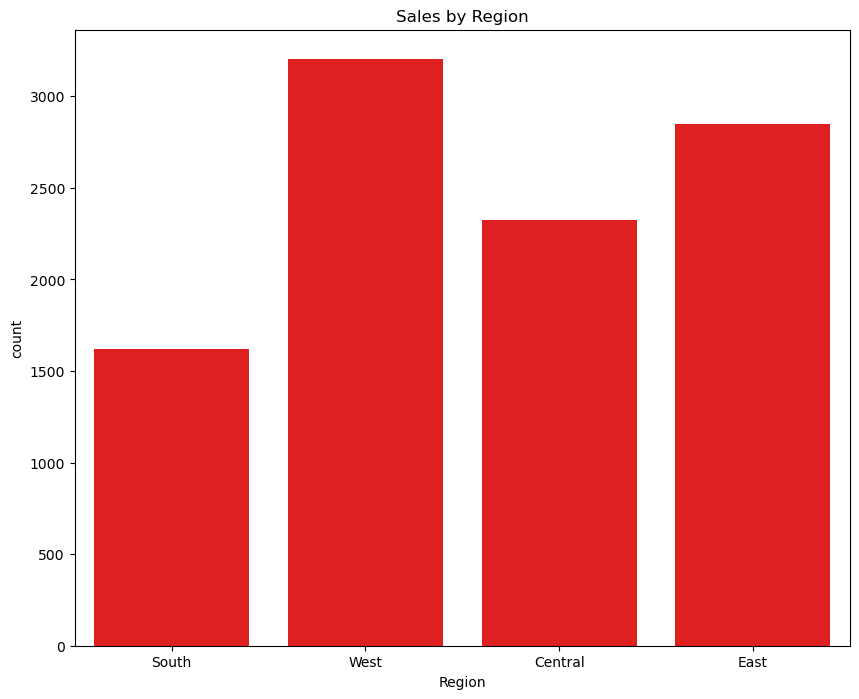

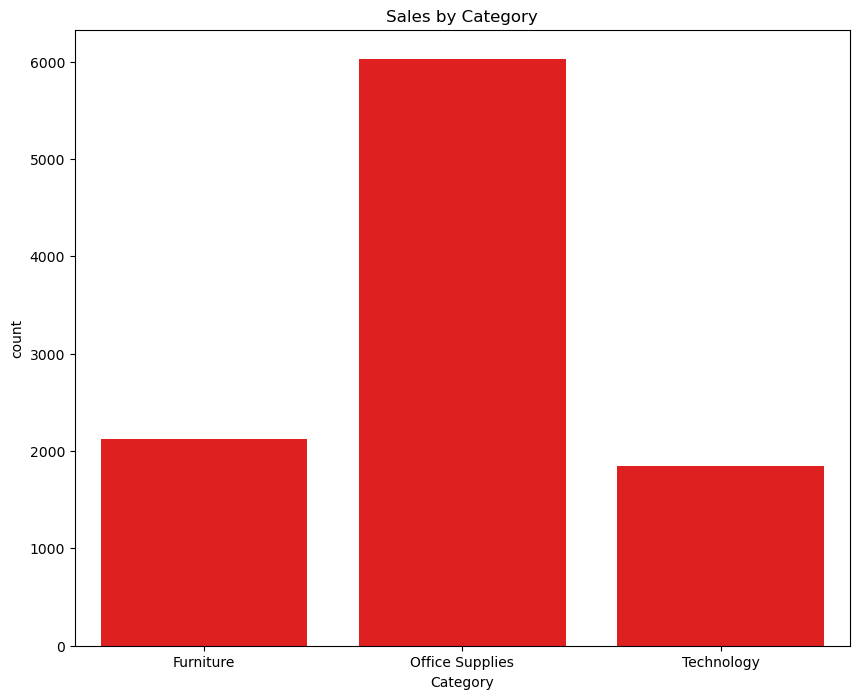

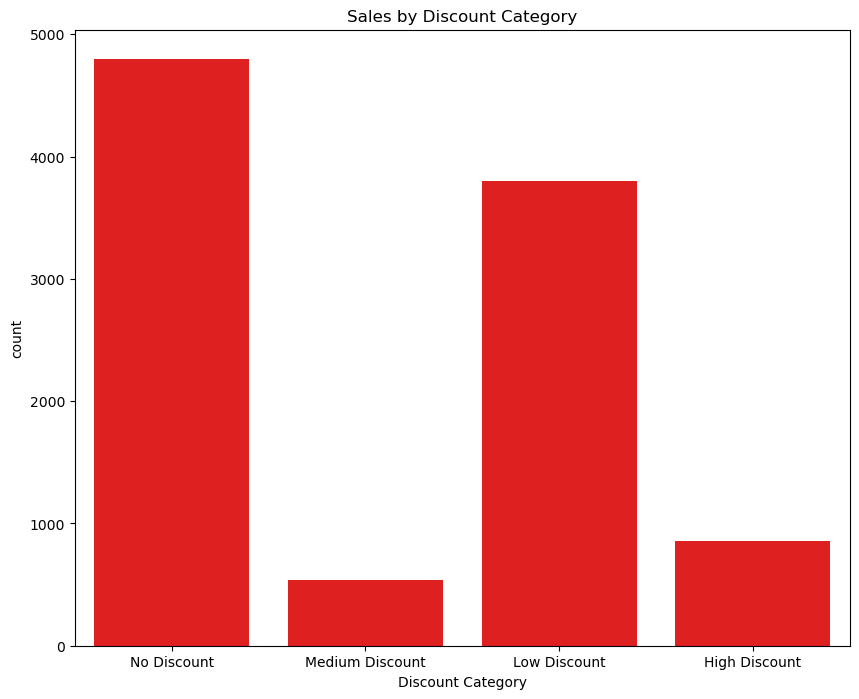

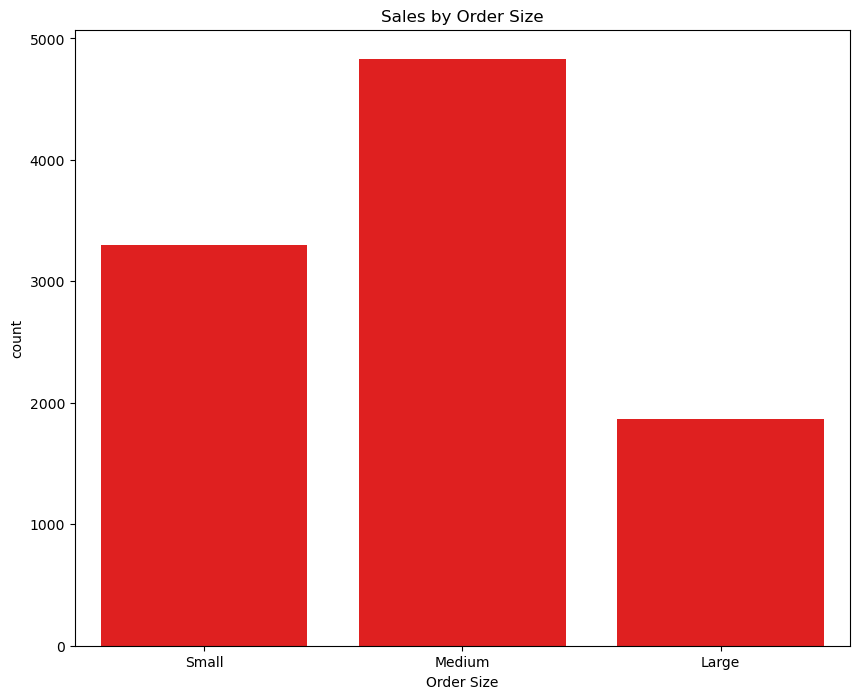

In [ ]:
for col in low_cardinality_cols:
    plt.figure(figsize=(10,8))
    sns.countplot(data=low_cardinality_cols,x=col,color='r')
    plt.title(f"Sales by {col}")
    plt.xlabel(col)
    plt.show()

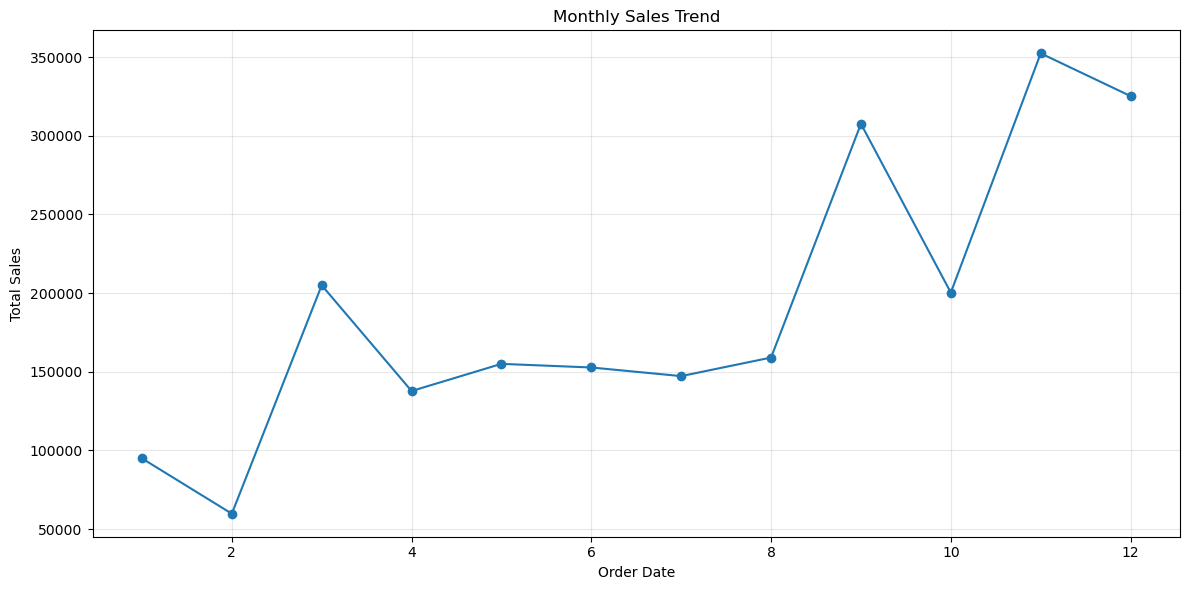

In [ ]:
# Monthly Sales Trend
monthly_sales = (
    df.groupby("Order_month")["Sales"]
      .sum()
)

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Order Date")
plt.ylabel("Total Sales")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../images/monthly_sales_trend.png", dpi=300, bbox_inches="tight")
plt.show()

## Bivariate Analysis

In [ ]:
cat_features.columns.to_list()

['Order ID',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Discount Category',
 'Order Size',
 'Order_month_name',
 'Ship_month_name']

In [ ]:
num_features.columns.to_list()

['Postal Code',
 'Sales',
 'Quantity',
 'Discount',
 'Profit',
 'Order_day',
 'Order_month',
 'Order_year',
 'Ship_day',
 'Ship_month',
 'Ship_year',
 'Shipping Time']

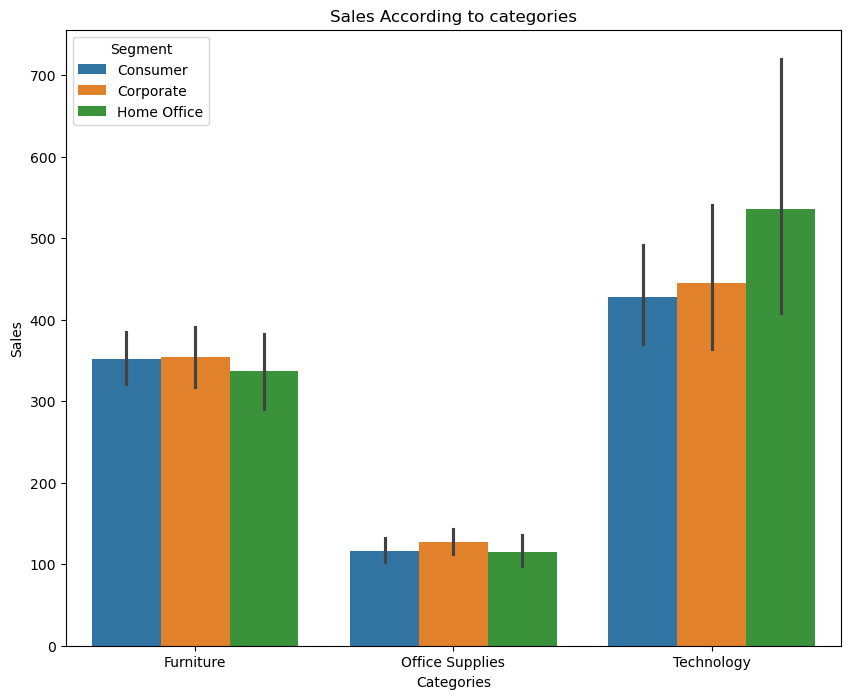

In [ ]:
plt.figure(figsize=(10,8))
sns.barplot(data=df,x=df['Category'],y=df['Sales'],hue="Segment")
plt.title("Sales According to categories")
plt.xlabel("Categories")
plt.ylabel("Sales")
plt.savefig("../images/category_wise_sale.png", dpi=300, bbox_inches="tight")

## Insight from graph :-
-- Category "Office Supplies " have least sales. Among them corporate have higher sale

-- The "Technology" Category have highest sales. Among them the Home Office Ordered more products

Text(0, 0.5, 'Sales')

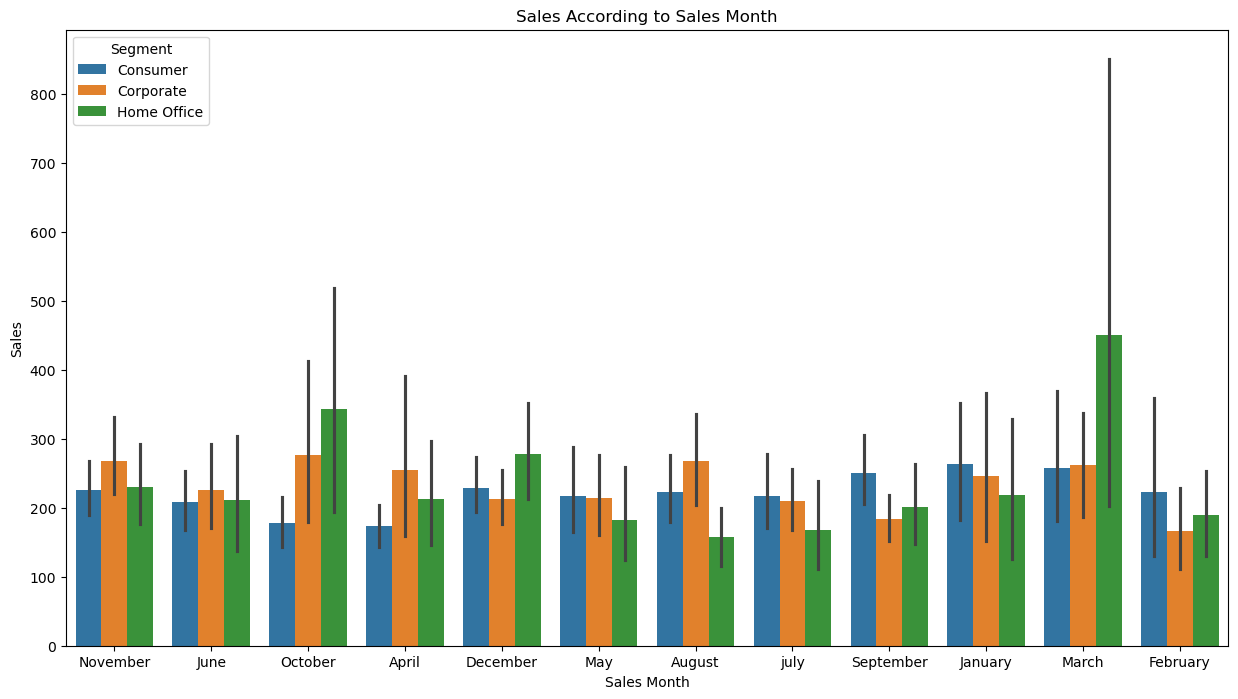

In [ ]:
plt.figure(figsize=(15,8))
sns.barplot(data=df,x=df['Order_month_name'],y=df['Sales'],hue="Segment")
plt.title("Sales According to Sales Month")
plt.xlabel("Sales Month")
plt.ylabel("Sales")

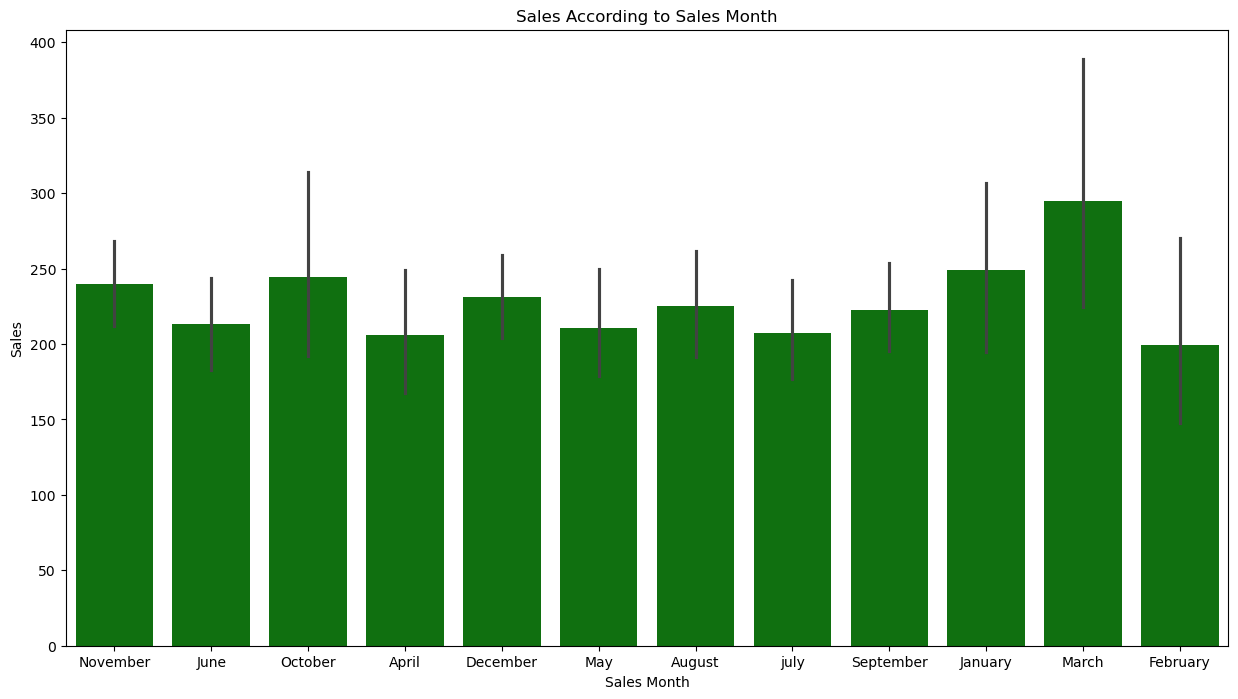

In [ ]:
plt.figure(figsize=(15,8))
sns.barplot(data=df,x=df['Order_month_name'],y=df['Sales'],color='green')
plt.title("Sales According to Sales Month")
plt.xlabel("Sales Month")
plt.ylabel("Sales")
plt.savefig("../images/month_wise_sale.png", dpi=300, bbox_inches="tight")

## Insights for Months:
-- In the month of 'March' the Home Office have higher sales and also March have highest sales among other months.

-- Except 'March' the first 7 month have slightly lower sales than last 5 months.

-- Also from below graph , the 'Home Office' have higher sales.

Text(0, 0.5, 'Sales')

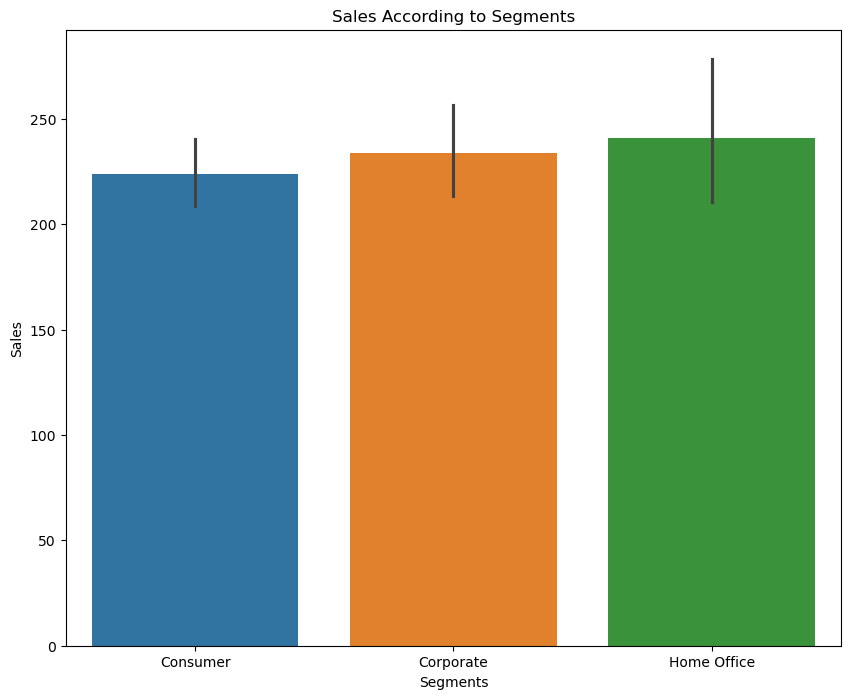

In [ ]:
plt.figure(figsize=(10,8))
sns.barplot(data=df,x=df['Segment'],y=df['Sales'],hue="Segment")
plt.title("Sales According to Segments")
plt.xlabel("Segments")
plt.ylabel("Sales")

Text(0, 0.5, 'Sales')

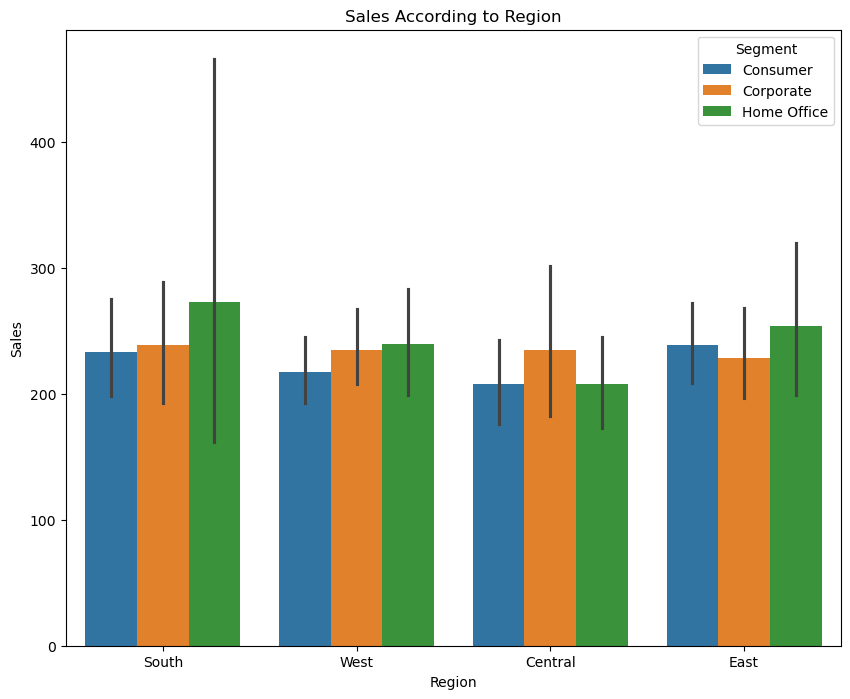

In [ ]:
plt.figure(figsize=(10,8))
sns.barplot(data=df,x=df['Region'],y=df['Sales'],hue="Segment")
plt.title("Sales According to Region")
plt.xlabel("Region")
plt.ylabel("Sales")

Text(0, 0.5, 'Sales')

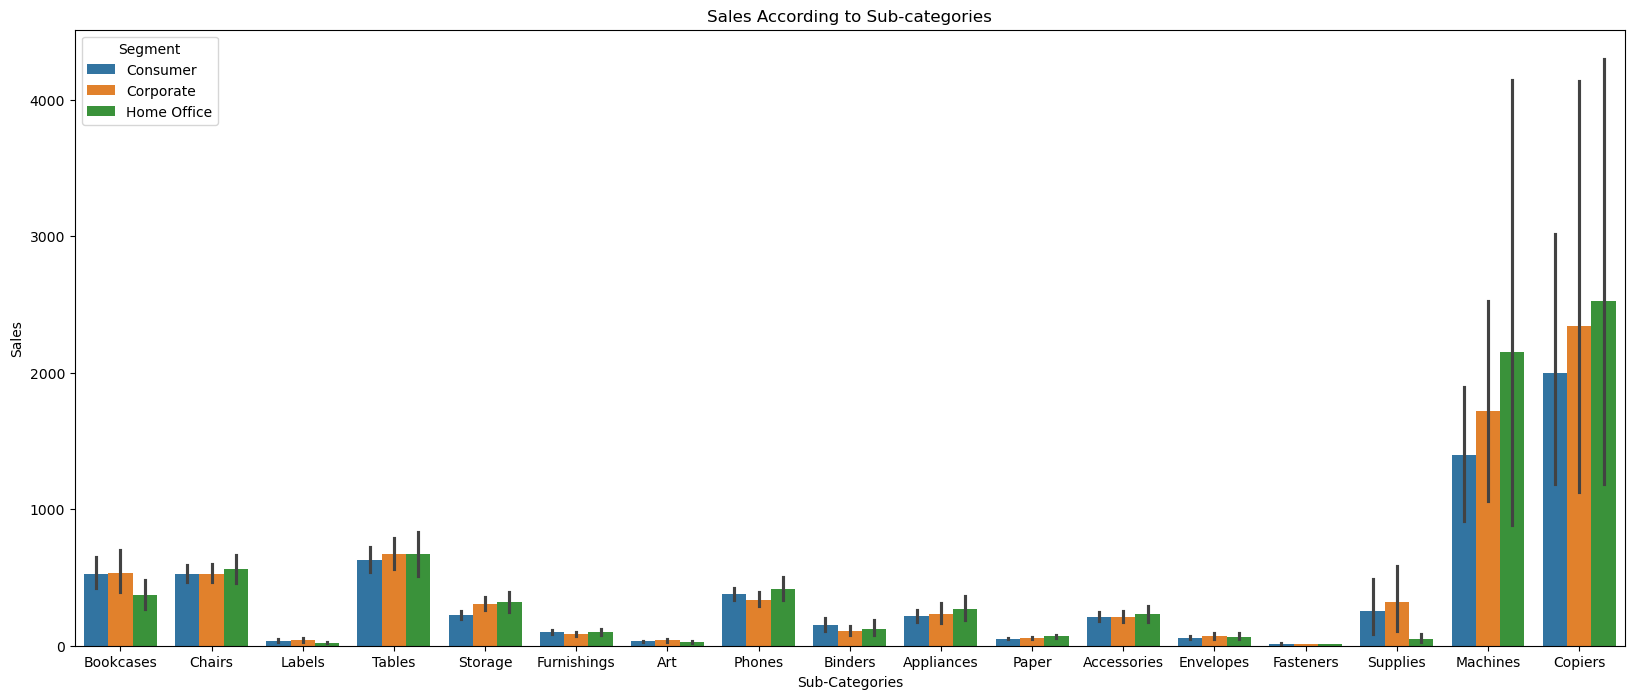

In [ ]:
plt.figure(figsize=(20,8))
sns.barplot(data=df,x=df['Sub-Category'],y=df['Sales'],hue="Segment")
plt.title("Sales According to Sub-categories")
plt.xlabel("Sub-Categories")
plt.ylabel("Sales")

Text(0, 0.5, 'Profit')

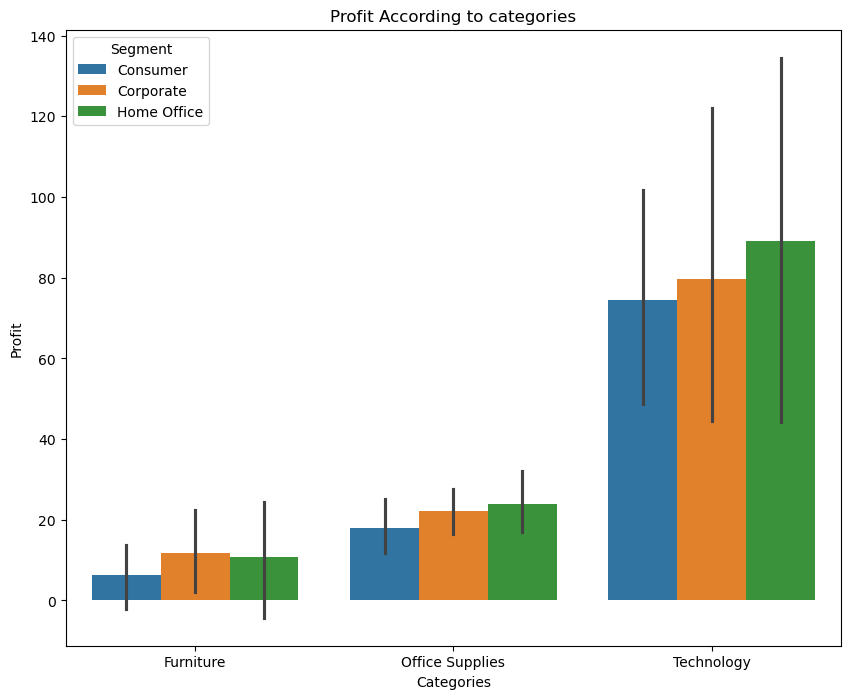

In [ ]:
plt.figure(figsize=(10,8))
sns.barplot(data=df,x=df['Category'],y=df['Profit'],hue="Segment")
plt.title("Profit According to categories")
plt.xlabel("Categories")
plt.ylabel("Profit")

In [ ]:
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order_day,Order_month,Order_year,Ship_day,Ship_month,Ship_year,Discount Category,Order Size,Shipping Time,Order_month_name,Ship_month_name
0,CA-2016-152156,2016-11-08,2016-11-08,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,8,11,2016,8,11,2016,No Discount,Small,0,November,November
1,CA-2016-152156,2016-11-08,2016-11-08,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,8,11,2016,8,11,2016,No Discount,Medium,0,November,November
2,CA-2016-138688,2016-06-12,2016-06-12,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,12,6,2016,12,6,2016,No Discount,Small,0,June,June
3,US-2015-108966,2015-10-11,2015-10-11,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,11,10,2015,11,10,2015,Medium Discount,Medium,0,October,October
4,US-2015-108966,2015-10-11,2015-10-11,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,11,10,2015,11,10,2015,Low Discount,Small,0,October,October


Text(0, 0.5, 'Profit')

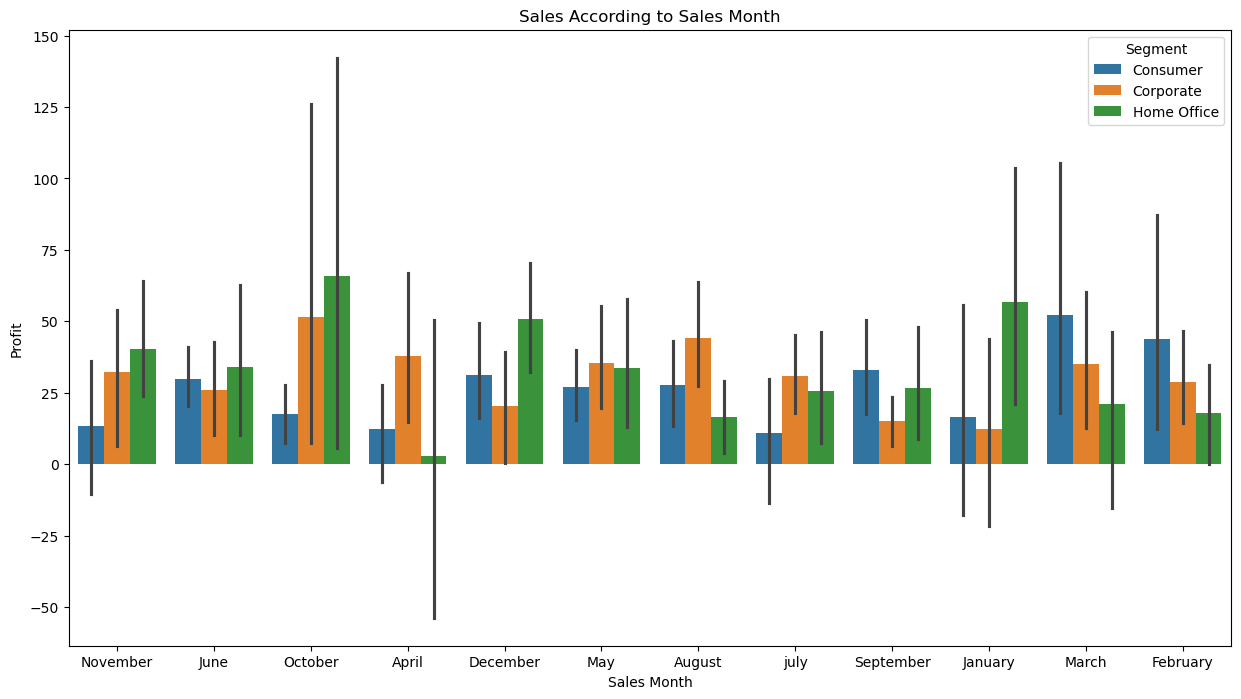

In [ ]:
plt.figure(figsize=(15,8))
sns.barplot(data=df,x=df['Order_month_name'],y=df['Profit'],hue="Segment")
plt.title("Sales According to Sales Month")
plt.xlabel("Sales Month")
plt.ylabel("Profit")

Text(0, 0.5, 'Profit')

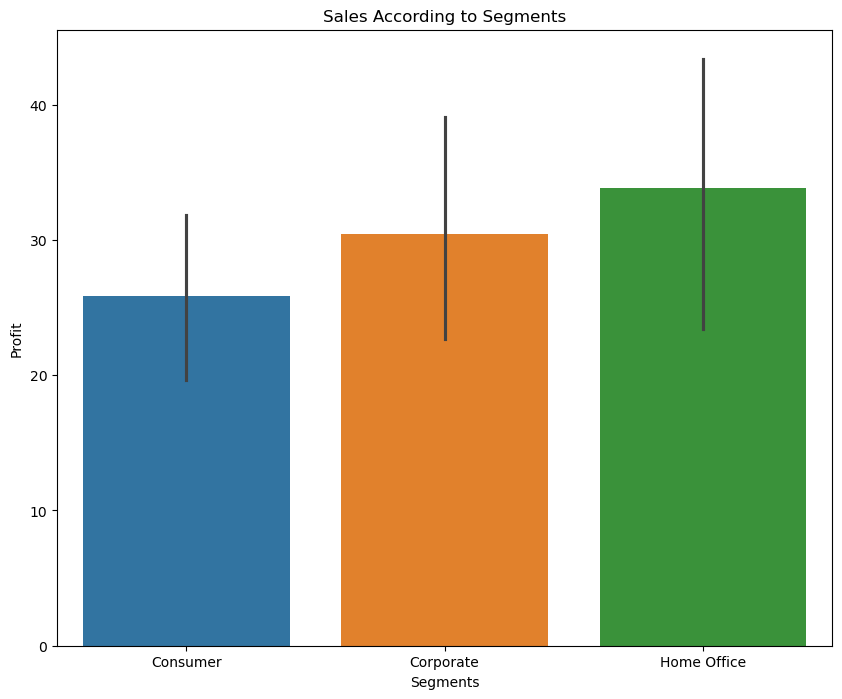

In [ ]:
plt.figure(figsize=(10,8))
sns.barplot(data=df,x=df['Segment'],y=df['Profit'],hue="Segment")
plt.title("Sales According to Segments")
plt.xlabel("Segments")
plt.ylabel("Profit")

Text(0, 0.5, 'Profit')

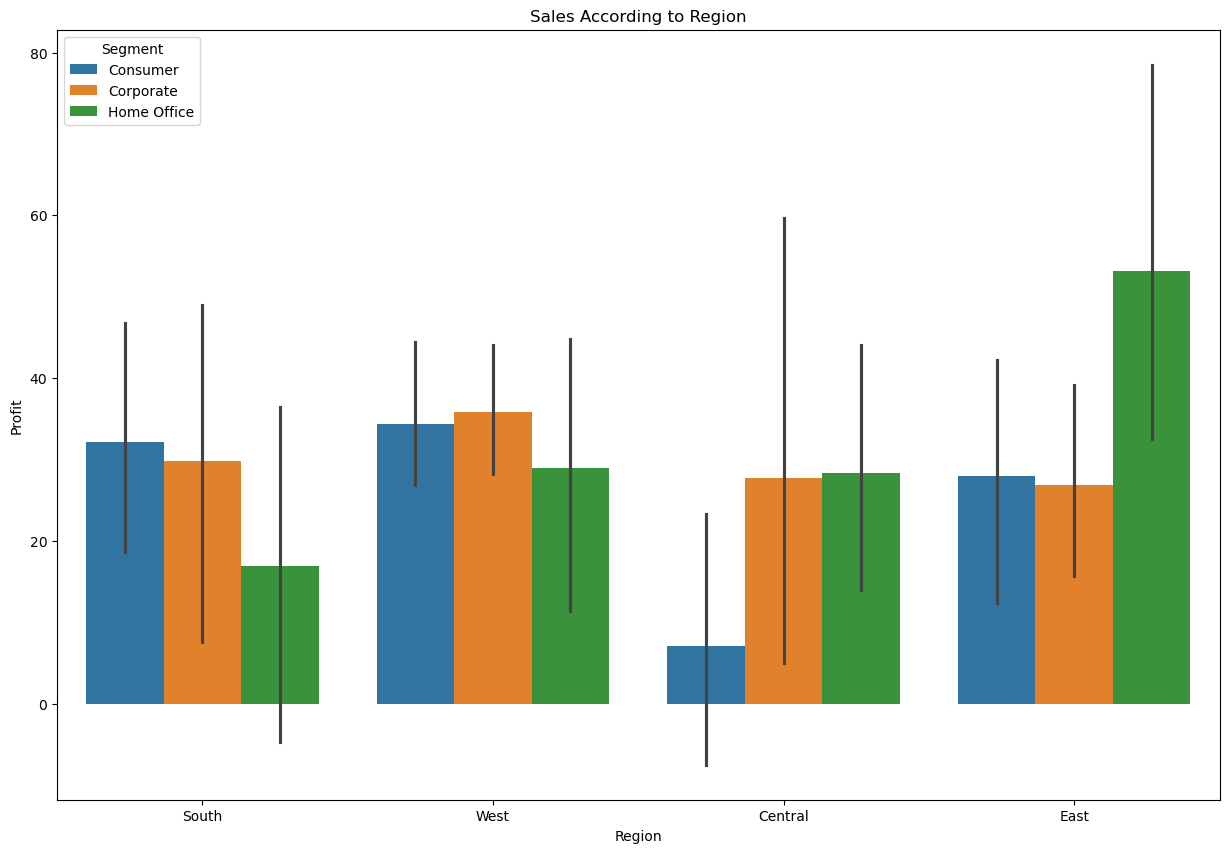

In [ ]:
plt.figure(figsize=(15,10))
sns.barplot(data=df,x=df['Region'],y=df['Profit'],hue="Segment")
plt.title("Sales According to Region")
plt.xlabel("Region")
plt.ylabel("Profit")

Text(0, 0.5, 'Profit')

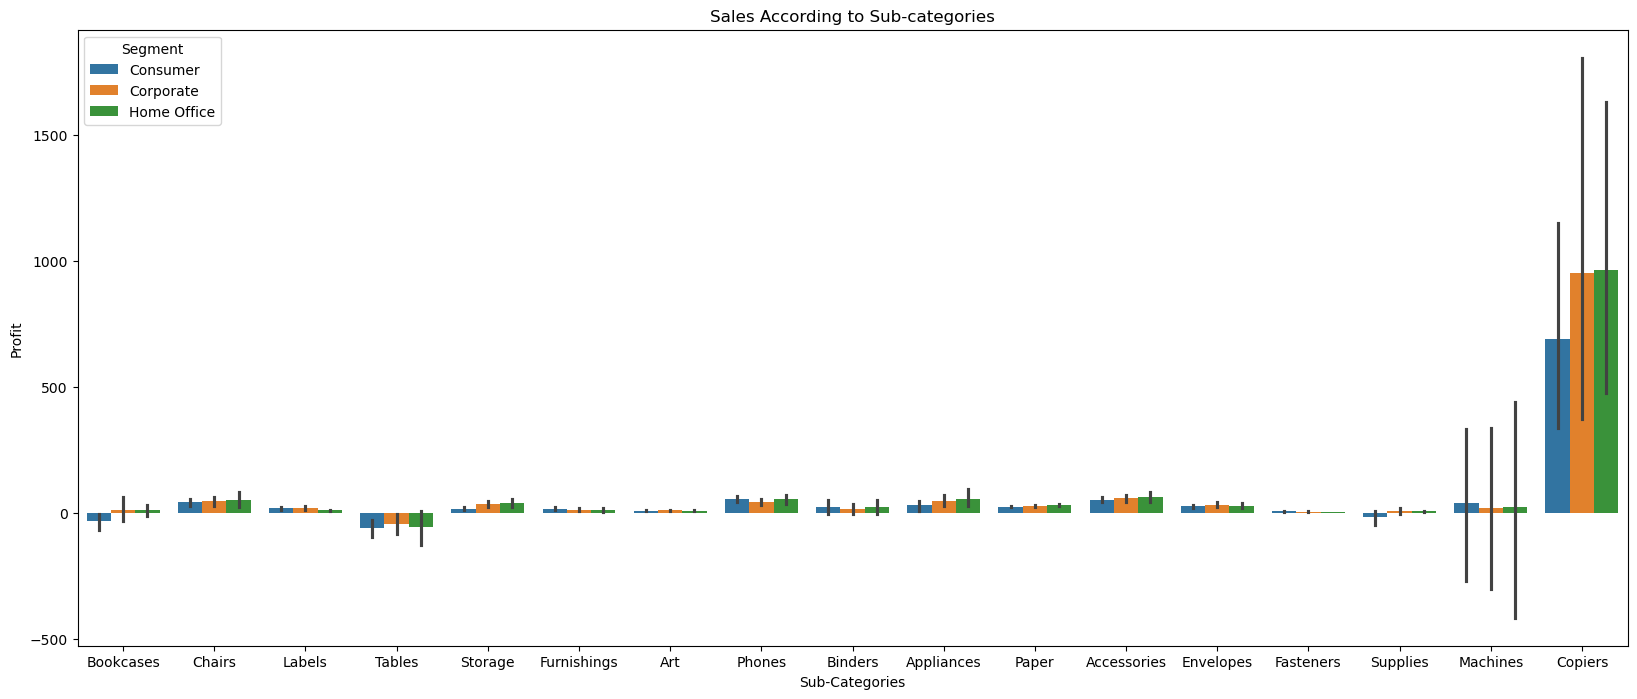

In [ ]:
plt.figure(figsize=(20,8))
sns.barplot(data=df,x=df['Sub-Category'],y=df['Profit'],hue="Segment")
plt.title("Sales According to Sub-categories")
plt.xlabel("Sub-Categories")
plt.ylabel("Profit")

Text(0, 0.5, 'Profit')

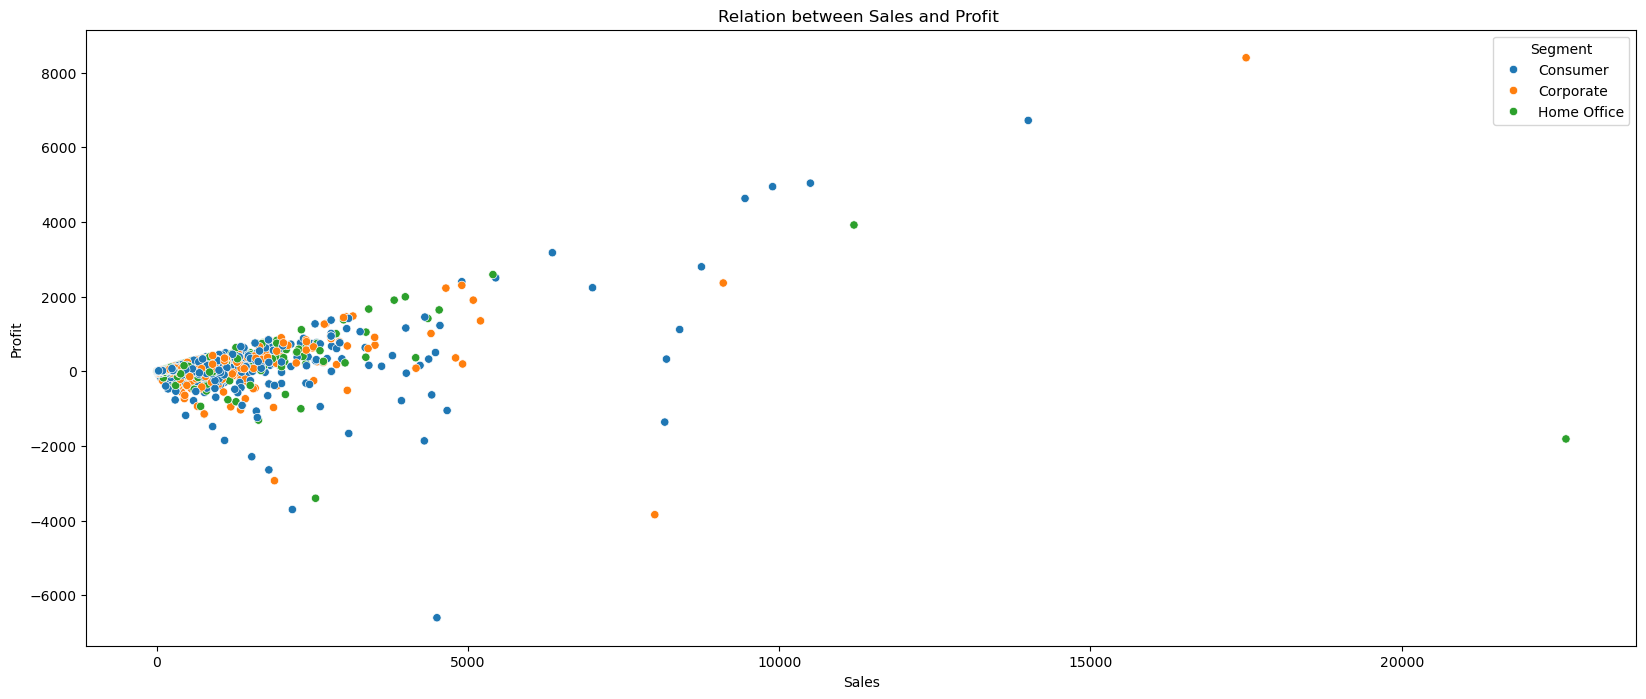

In [ ]:
plt.figure(figsize=(20,8))
sns.scatterplot(data=df,x=df['Sales'],y=df['Profit'],hue="Segment")
plt.title("Relation between Sales and Profit ")
plt.xlabel("Sales")
plt.ylabel("Profit")

Text(0, 0.5, 'Profit')

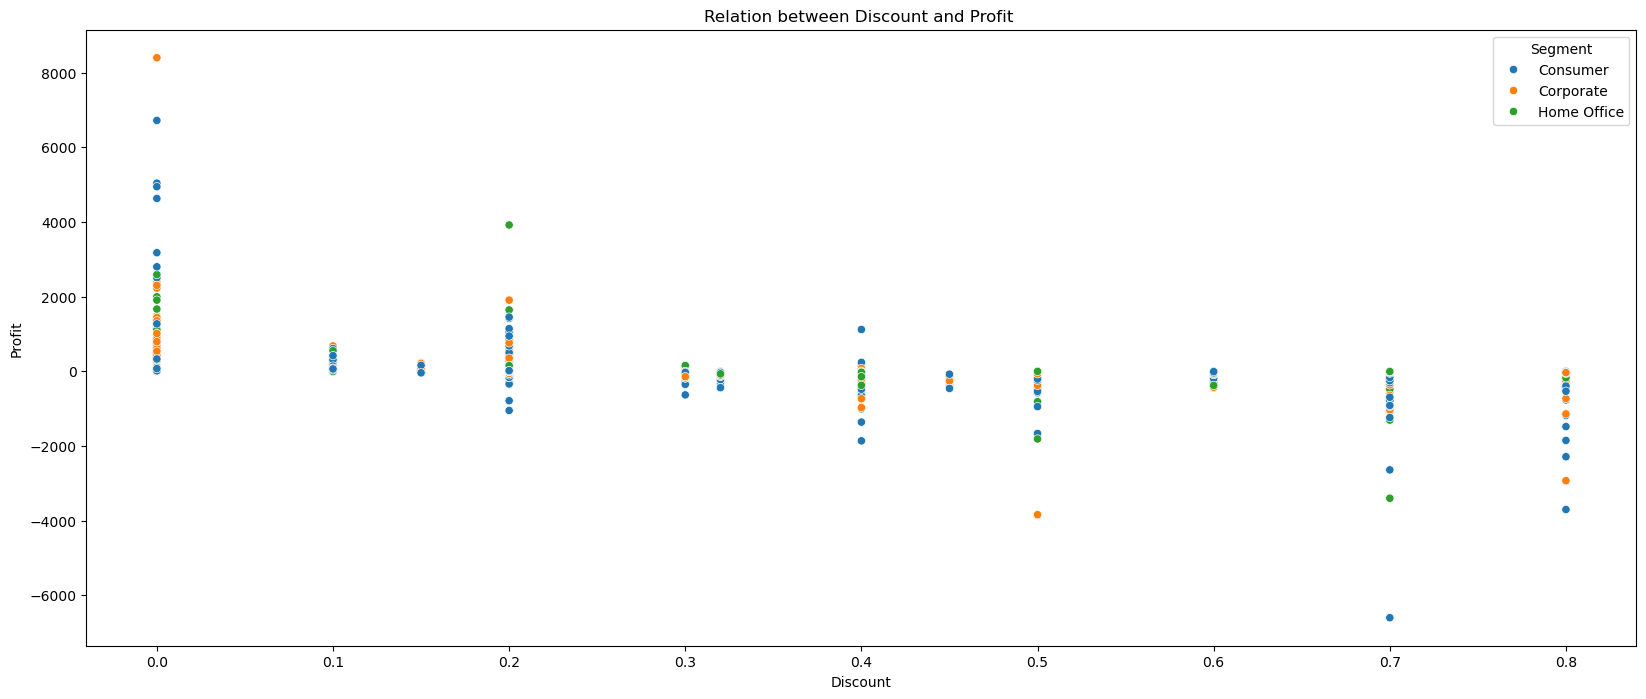

In [ ]:
plt.figure(figsize=(20,8))
sns.scatterplot(data=df,x=df['Discount'],y=df['Profit'],hue="Segment")
plt.title("Relation between Discount and Profit ")
plt.xlabel("Discount")
plt.ylabel("Profit")

Text(0, 0.5, 'Sales')

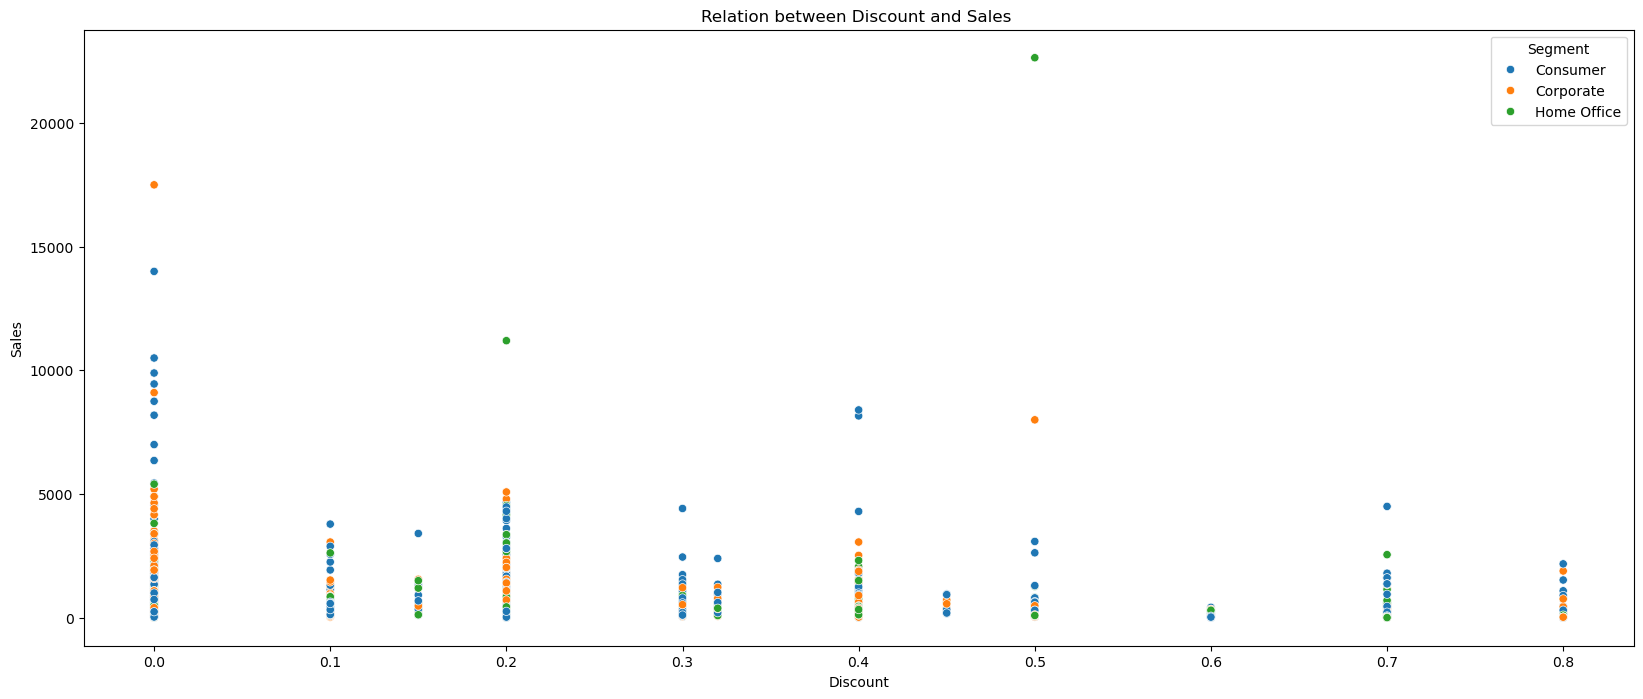

In [ ]:
plt.figure(figsize=(20,8))
sns.scatterplot(data=df,x=df['Discount'],y=df['Sales'],hue="Segment")
plt.title("Relation between Discount and Sales ")
plt.xlabel("Discount")
plt.ylabel("Sales")

In [ ]:
num_corr = num_features.corr()

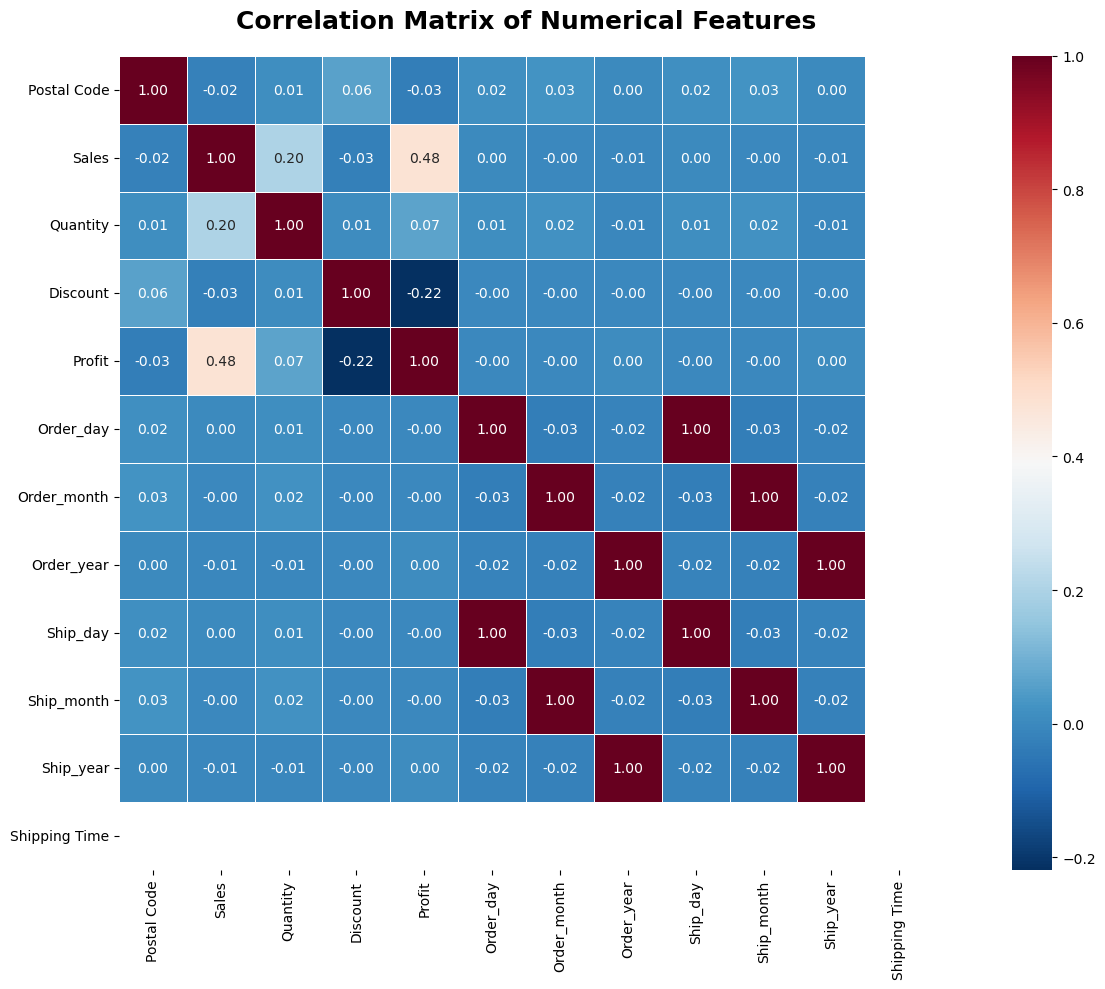

In [ ]:
plt.figure(figsize=(16, 10))
sns.heatmap(num_corr,annot=True,fmt=".2f",cmap="RdBu_r",linewidths=0.5,linecolor="white",square=True)
plt.title("Correlation Matrix of Numerical Features",fontsize=18,fontweight="bold",pad=20)
plt.tight_layout()
plt.savefig("../images/correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
cat_features


,Order ID,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Discount Category,Order Size,Order_month_name,Ship_month_name
0,CA-2016-152156,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,No Discount,Small,November,November
1,CA-2016-152156,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",No Discount,Medium,November,November
2,CA-2016-138688,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,No Discount,Small,June,June
3,US-2015-108966,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,Medium Discount,Medium,October,October
4,US-2015-108966,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,Low Discount,Small,October,October
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,CA-2014-110422,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,Florida,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,Low Discount,Medium,January,January
9990,CA-2017-121258,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,No Discount,Small,February,February
9991,CA-2017-121258,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,Low Discount,Small,February,February
9992,CA-2017-121258,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",No Discount,Medium,February,February


## Business Insights from the dataset :arrow_down:

## Top 10 customer with maximum profit

In [ ]:
customers_by_profit = (
    df.groupby('Customer Name')['Profit']
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .reset_index()
)

customers_by_profit


,Customer Name,Profit
0,Tamara Chand,8981.3239
1,Raymond Buch,6976.0959
2,Sanjit Chand,5757.4119
3,Hunter Lopez,5622.4292
4,Adrian Barton,5444.8055
5,Tom Ashbrook,4703.7883
6,Christopher Martinez,3899.8904
7,Keith Dawkins,3038.6254
8,Andy Reiter,2884.6208
9,Daniel Raglin,2869.0760


## Top 10 customer with maximum Sales

In [ ]:
customer_by_sales = (
    df.groupby('Customer Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)


customer_by_sales

,Customer Name,Sales
0,Sean Miller,25043.050
1,Tamara Chand,19052.218
2,Raymond Buch,15117.339
3,Tom Ashbrook,14595.620
4,Adrian Barton,14473.571
5,Ken Lonsdale,14175.229
6,Sanjit Chand,14142.334
7,Hunter Lopez,12873.298
8,Sanjit Engle,12209.438
9,Christopher Conant,12129.072


## Top 10 Customers with highest order value


In [ ]:
avg_order_value = (
    df.groupby('Customer Name')['Sales']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

avg_order_value

,Customer Name,Sales
0,Mitch Willingham,1751.292000
1,Sean Miller,1669.536667
2,Tamara Chand,1587.684833
3,Grant Thornton,1558.535333
4,Tom Ashbrook,1459.562000
5,Hunter Lopez,1170.299818
6,Bill Shonely,1166.850333
7,Christopher Conant,1102.642909
8,Stefanie Holloman,1048.196000
9,Christopher Martinez,895.402000


## Top 10 Repeated customers
-- The customers with most numbers of ordered product

In [ ]:
repeated_Customer = (
    df.groupby('Customer Name')['Order ID']
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name='No of orders')
)

repeated_Customer = repeated_Customer[repeated_Customer['No of orders']>1]


repeated_Customer.head(10)

,Customer Name,No of orders
0,Emily Phan,17
1,Sally Hughsby,13
2,Erin Ashbrook,13
3,Patrick Gardner,13
4,Zuschuss Carroll,13
5,Chloris Kastensmidt,13
6,Joel Eaton,13
7,Noel Staavos,13
8,Rick Bensley,12
9,Resi Pölking,12


In [ ]:
cat_features.head(1)

,Order ID,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Discount Category,Order Size,Order_month_name,Ship_month_name
0,CA-2016-152156,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,No Discount,Small,November,November


## Top 10 most sold products

In [ ]:
most_selling = (
    df.groupby('Product Name')['Product ID']
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="No of product")
)
most_selling.head(10)

,Product Name,No of product
0,Staples,10
1,Staple envelope,9
2,Easy-staple paper,8
3,Staples in misc. colors,7
4,Staple holder,3
5,Staple remover,3
6,Prang Drawing Pencil Set,2
7,Eldon Wave Desk Accessories,2
8,KI Adjustable-Height Table,2
9,"Peel & Seel Recycled Catalog Envelopes, Brown",2


## Top 10 products with highest profit 

In [ ]:
most_profitable = (
    df.groupby('Product Name')['Profit']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
most_profitable.head(10)

,Product Name,Profit
0,Canon imageCLASS 2200 Advanced Copier,25199.9280
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,7753.0390
2,Hewlett Packard LaserJet 3310 Copier,6983.8836
3,Canon PC1060 Personal Laser Copier,4570.9347
4,HP Designjet T520 Inkjet Large Format Printer ...,4094.9766
5,Ativa V4110MDD Micro-Cut Shredder,3772.9461
6,"3D Systems Cube Printer, 2nd Generation, Magenta",3717.9714
7,Plantronics Savi W720 Multi-Device Wireless He...,3696.2820
8,Ibico EPK-21 Electric Binding System,3345.2823
9,Zebra ZM400 Thermal Label Printer,3343.5360


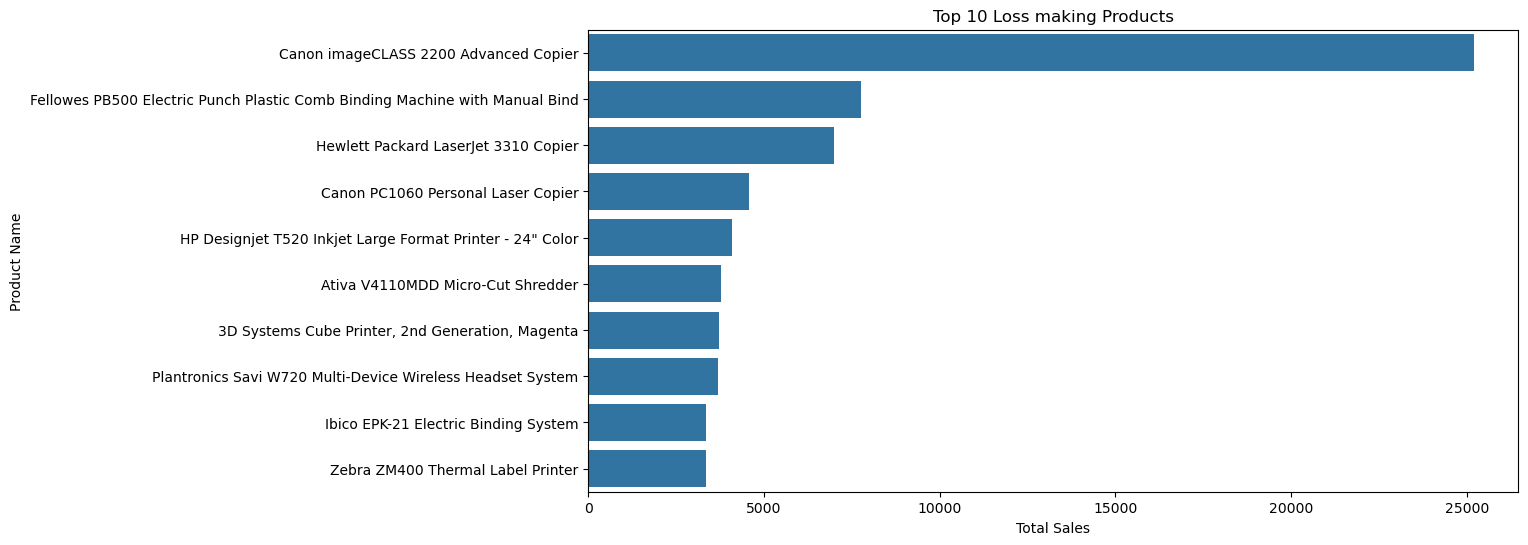

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=most_profitable.head(10),
    x='Profit',
    y='Product Name'
)

plt.title("Top 10 Loss making Products")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")
plt.show()
plt.savefig("../images/most_profitable_products.png", dpi=300, bbox_inches="tight")

## Loss making products 

In [ ]:
lost_making_product = (
    df.groupby('Product Name')['Profit']
    .sum()
    .sort_values(ascending=True)
    .reset_index()
)
lost_making_product.head(10)

,Product Name,Profit
0,Cubify CubeX 3D Printer Double Head Print,-8879.9704
1,Lexmark MX611dhe Monochrome Laser Printer,-4589.9730
2,Cubify CubeX 3D Printer Triple Head Print,-3839.9904
3,Chromcraft Bull-Nose Wood Oval Conference Tabl...,-2876.1156
4,Bush Advantage Collection Racetrack Conference...,-1934.3976
5,GBC DocuBind P400 Electric Binding System,-1878.1662
6,Cisco TelePresence System EX90 Videoconferenci...,-1811.0784
7,Martin Yale Chadless Opener Electric Letter Op...,-1299.1836
8,Balt Solid Wood Round Tables,-1201.0581
9,BoxOffice By Design Rectangular and Half-Moon ...,-1148.4375


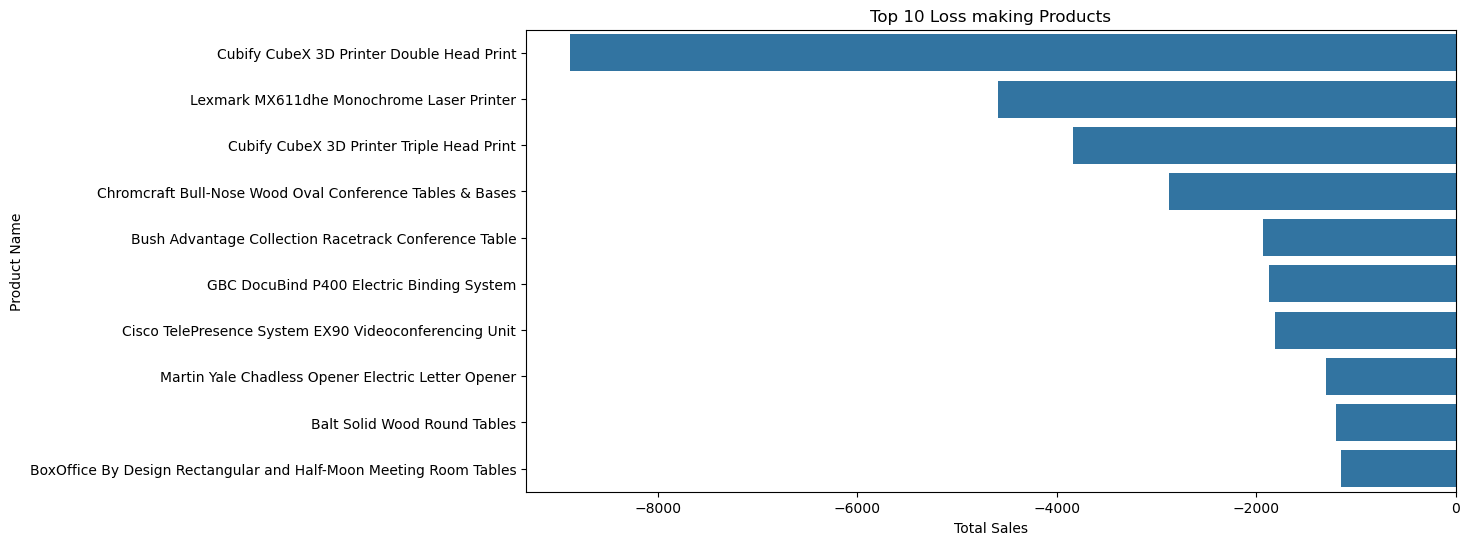

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=lost_making_product.head(10),
    x='Profit',
    y='Product Name'
)

plt.title("Top 10 Loss making Products")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")
plt.show()
plt.savefig("../images/loss_making_products.png", dpi=300, bbox_inches="tight")


## Best sold products 

In [ ]:
best_selling = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
best_selling.head(10)

,Product Name,Sales
0,Canon imageCLASS 2200 Advanced Copier,61599.824
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
2,Cisco TelePresence System EX90 Videoconferenci...,22638.480
3,HON 5400 Series Task Chairs for Big and Tall,21870.576
4,GBC DocuBind TL300 Electric Binding System,19823.479
5,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
6,Hewlett Packard LaserJet 3310 Copier,18839.686
7,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
8,GBC DocuBind P400 Electric Binding System,17965.068
9,High Speed Automatic Electric Letter Opener,17030.312


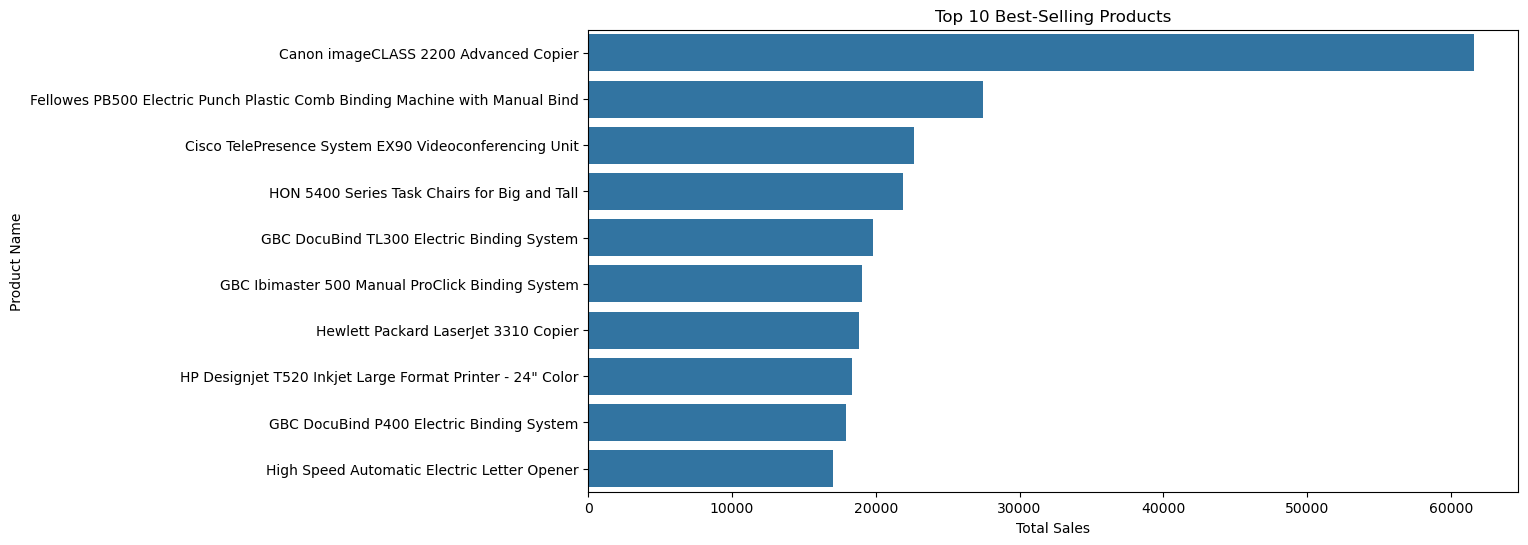

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=best_selling.head(10),
    x='Sales',
    y='Product Name'
)

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")
plt.show()

## Worst selling products

In [ ]:
worst_selling = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=True)
    .reset_index()
)
worst_selling.head(10)

,Product Name,Sales
0,Eureka Disposable Bags for Sanitaire Vibra Gro...,1.624
1,Avery 5,5.760
2,Xerox 20,6.480
3,Grip Seal Envelopes,7.072
4,Avery Hi-Liter Pen Style Six-Color Fluorescent...,7.700
5,Avery Hi-Liter Comfort Grip Fluorescent Highli...,7.800
6,Xerox 1989,7.968
7,4009 Highlighters,8.040
8,Stockwell Gold Paper Clips,8.096
9,Newell 308,8.400


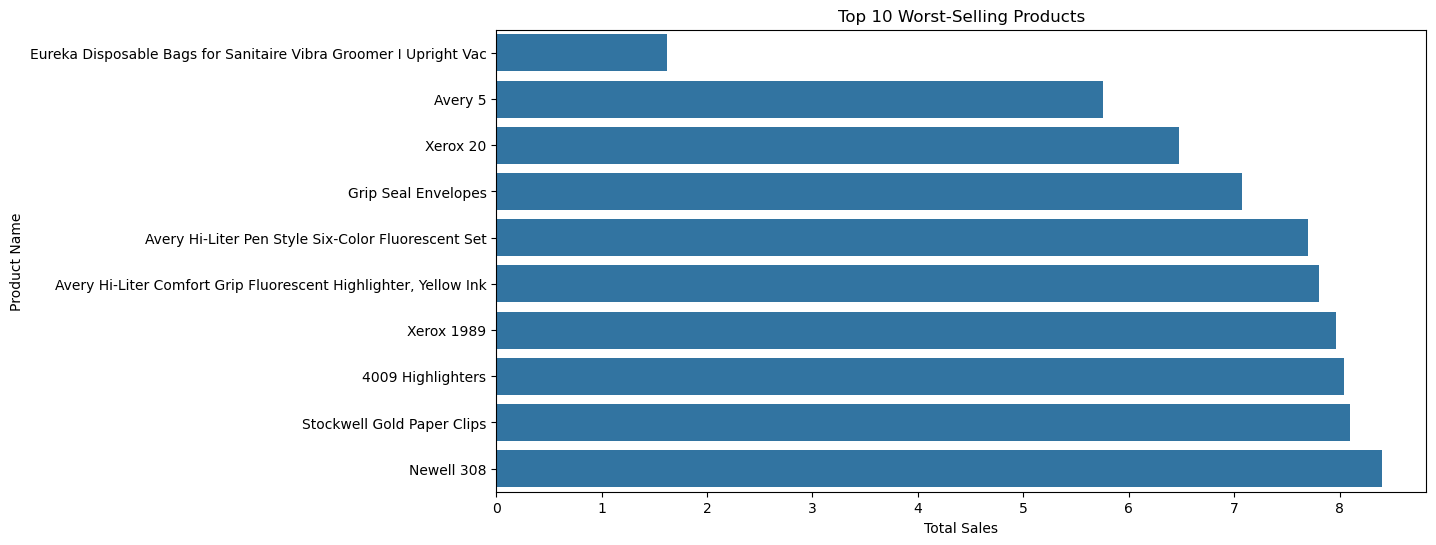

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=worst_selling.head(10),
    x='Sales',
    y='Product Name'
)

plt.title("Top 10 Worst-Selling Products")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")
plt.show()

In [ ]:
# Save DataFrame to CSV
df.to_csv("cleaned_superstore_data.csv", index=False)